<a href="https://colab.research.google.com/github/Lateephah/Loan-Default-Risk-Predictor-Micro-Lenders-POS-Agents-Nigeria-/blob/main/loan_default_risk_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loan Default Risk Model**: Micro-Lenders & POS Agents

**Capstone Project:** A tabular machine learning model predicting the likelihood of loan default,
built for micro-lenders and POS (Point-of-Sale) agents in Nigeria who need fast, defensible
repayment-risk checks before disbursing small, short-tenor loans.

**MVP features covered in this notebook:** CSV / manual input scoring, risk score, key risk, feature importance confusion matrix.


## 1. Problem Context

Across Nigeria, POS agents and micro-lenders extend small, short-term loans to informal
traders, artisans, and small business owners  often with little formal credit history to
go on. A wrong decision is costly in both directions: lending to a high-risk borrower risks
non-repayment, while rejecting a genuinely low-risk borrower loses income and excludes someone
who may be perfectly creditworthy.

This project builds a lightweight, explainable risk-scoring model that a micro-lender or POS
agent could realistically use at the point of a lending decision, fed either a single
applicant's details (manual input) or a batch of applicants (CSV upload), to get back a
risk score, a plain-language explanation of *why*, and enough transparency to trust (or
challenge) the model's call.


## 2. Data Source

**No public, row-level loan-default dataset exists for the Nigerian micro-lending / POS-agent
market.** This kind of individual borrower data is proprietary to lenders and protected under
banking privacy regulation; confirmed by checking CBN's public data (Statistical Bulletins,
Financial Stability & Microfinance Reports), which only publish **aggregate** statistics
(sector-level NPL ratios, interest rate trends), not row-level borrower records.

**Approach taken:** a documented **synthetic dataset** (20,000 records) generated specifically
to reflect the Nigerian micro-lending / POS-agent context, including features not present in
any generic global credit dataset, such as POS transaction volume/frequency, loan channel
(POS Agent / Bank Branch / Mobile App / Cooperative), trade/market association membership
(Esusu/Ajo), mobile money wallet usage, and SIM tenure (a real informal underwriting signal
used by Nigerian fintechs).

The `defaulted` outcome is **not random**, it is generated from a transparent logistic
combination of realistic risk drivers (debt-to-income ratio, repayment history, collateral,
existing loan burden, business tenure, trade association membership, etc.) plus noise, so the
dataset has genuine, learnable structure rather than being pure noise dressed up as data.

**Known limitation, stated plainly:** this is synthetic data. Model performance and feature
importances reflect the *logic used to generate it*, not verified real-world Nigerian lending
outcomes. This is an appropriate and explicitly permitted approach for a technique-focused
capstone brief where no real dataset can exist publicly, but it should not be mistaken for a
validated real-world risk model without further validation on real lender data.


#IMPORTING RELEVANT LIBRARIES

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay,
)

from xgboost import XGBClassifier



#IMPORTING THE DATASET

In [160]:
df = pd.read_csv("/content/drive/MyDrive/loan_default_predictor/synthetic_loan_data.csv")

The synthetic loan dataset was successfully loaded into the notebook for exploratory analysis.

The dataset contains borrower demographics, business information, financial characteristics, transaction behavior, and historical repayment records designed to simulate lending scenarios commonly encountered by Nigerian microfinance institutions, POS agents, and digital lenders.

#EXPLORATORY DATA ANALYSIS

## Initial Data Inspection

In [161]:
df.head()

,borrower_id,age,gender,state,business_sector,years_in_business,monthly_income_ngn,pos_txn_count_monthly,pos_txn_volume_ngn_monthly,loan_amount_ngn,...,existing_loans_count,collateral_provided,has_bank_account,urban_rural,loan_channel,trade_association_member,mobile_money_active,sim_tenure_months,repayment_history_score,defaulted
0,BRW100000,22,Female,Kano,Fashion & Tailoring,3.8,27300,42,184500,21000,...,1,0,1,Urban,POS Agent,1,1,53,51.3,1
1,BRW100001,55,Female,Kaduna,Fashion & Tailoring,5.1,39300,88,489200,54000,...,0,0,1,Urban,POS Agent,1,0,102,99.3,0
2,BRW100002,49,Male,Abuja (FCT),Trading/Retail,3.1,16500,53,201200,14000,...,1,1,1,Urban,Mobile App,1,0,27,73.8,0
3,BRW100003,39,Male,Ogun,Trading/Retail,0.6,57300,8,11300,44000,...,0,0,0,Rural,Mobile App,1,1,100,73.8,0
4,BRW100004,38,Male,Rivers,Agriculture,1.7,46900,34,185600,101000,...,0,1,1,Urban,POS Agent,1,0,40,68.4,0


,borrower_id,age,gender,state,business_sector,years_in_business,monthly_income_ngn,pos_txn_count_monthly,pos_txn_volume_ngn_monthly,loan_amount_ngn,...,existing_loans_count,collateral_provided,has_bank_account,urban_rural,loan_channel,trade_association_member,mobile_money_active,sim_tenure_months,repayment_history_score,defaulted
0,BRW100000,22,Female,Kano,Fashion & Tailoring,3.8,27300,42,184500,21000,...,1,0,1,Urban,POS Agent,1,1,53,51.3,1
1,BRW100001,55,Female,Kaduna,Fashion & Tailoring,5.1,39300,88,489200,54000,...,0,0,1,Urban,POS Agent,1,0,102,99.3,0
2,BRW100002,49,Male,Abuja (FCT),Trading/Retail,3.1,16500,53,201200,14000,...,1,1,1,Urban,Mobile App,1,0,27,73.8,0
3,BRW100003,39,Male,Ogun,Trading/Retail,0.6,57300,8,11300,44000,...,0,0,0,Rural,Mobile App,1,1,100,73.8,0
4,BRW100004,38,Male,Rivers,Agriculture,1.7,46900,34,185600,101000,...,0,1,1,Urban,POS Agent,1,0,40,68.4,0


The dataset contains borrower-level records covering demographic information, business profile, financial activity, loan characteristics, and repayment history. The target variable (`defaulted`) is already available, making the dataset suitable for supervised binary classification.

In [162]:
df.columns

Index(['borrower_id', 'age', 'gender', 'state', 'business_sector',
       'years_in_business', 'monthly_income_ngn', 'pos_txn_count_monthly',
       'pos_txn_volume_ngn_monthly', 'loan_amount_ngn', 'loan_tenor_months',
       'interest_rate_monthly_pct', 'existing_loans_count',
       'collateral_provided', 'has_bank_account', 'urban_rural',
       'loan_channel', 'trade_association_member', 'mobile_money_active',
       'sim_tenure_months', 'repayment_history_score', 'defaulted'],
      dtype='object')

Index(['borrower_id', 'age', 'gender', 'state', 'business_sector',
       'years_in_business', 'monthly_income_ngn', 'pos_txn_count_monthly',
       'pos_txn_volume_ngn_monthly', 'loan_amount_ngn', 'loan_tenor_months',
       'interest_rate_monthly_pct', 'existing_loans_count',
       'collateral_provided', 'has_bank_account', 'urban_rural',
       'loan_channel', 'trade_association_member', 'mobile_money_active',
       'sim_tenure_months', 'repayment_history_score', 'defaulted'],
      dtype='object')

The dataset contains **22 variables**, including borrower identifiers, demographic attributes, business characteristics, transaction behavior, loan information, and repayment indicators.

These variables provide multiple perspectives that can potentially explain loan repayment risk.

## Statistical Summary

In [163]:
df.describe()

,age,years_in_business,monthly_income_ngn,pos_txn_count_monthly,pos_txn_volume_ngn_monthly,loan_amount_ngn,loan_tenor_months,interest_rate_monthly_pct,existing_loans_count,collateral_provided,has_bank_account,trade_association_member,mobile_money_active,sim_tenure_months,repayment_history_score,defaulted
count,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,41.334500,4.398535,56667.880000,65.963900,2.232181e+05,79337.400000,4.585250,7.480682,0.792050,0.350750,0.782900,0.339050,0.617950,48.198900,69.630930,0.154400
std,13.832313,3.131553,34147.328128,47.598481,2.017057e+05,63662.559698,3.431621,2.597835,0.891093,0.477217,0.412282,0.473399,0.485901,32.122457,17.329727,0.361341
min,18.000000,0.100000,15000.000000,0.000000,0.000000e+00,10000.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,29.000000,2.100000,33500.000000,31.000000,8.140000e+04,36000.000000,2.000000,5.230000,0.000000,0.000000,1.000000,0.000000,0.000000,24.000000,57.900000,0.000000
50%,41.000000,3.700000,48500.000000,55.000000,1.641000e+05,62000.000000,3.000000,7.480000,1.000000,0.000000,1.000000,0.000000,1.000000,41.000000,70.000000,0.000000
75%,53.000000,5.900000,70500.000000,89.000000,3.003000e+05,103000.000000,6.000000,9.720000,1.000000,1.000000,1.000000,1.000000,1.000000,65.000000,82.325000,0.000000
max,65.000000,25.000000,584600.000000,388.000000,2.155700e+06,939000.000000,12.000000,12.000000,7.000000,1.000000,1.000000,1.000000,1.000000,180.000000,100.000000,1.000000


,age,years_in_business,monthly_income_ngn,pos_txn_count_monthly,pos_txn_volume_ngn_monthly,loan_amount_ngn,loan_tenor_months,interest_rate_monthly_pct,existing_loans_count,collateral_provided,has_bank_account,trade_association_member,mobile_money_active,sim_tenure_months,repayment_history_score,defaulted
count,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,41.334500,4.398535,56667.880000,65.963900,2.232181e+05,79337.400000,4.585250,7.480682,0.792050,0.350750,0.782900,0.339050,0.617950,48.198900,69.630930,0.154400
std,13.832313,3.131553,34147.328128,47.598481,2.017057e+05,63662.559698,3.431621,2.597835,0.891093,0.477217,0.412282,0.473399,0.485901,32.122457,17.329727,0.361341
min,18.000000,0.100000,15000.000000,0.000000,0.000000e+00,10000.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,29.000000,2.100000,33500.000000,31.000000,8.140000e+04,36000.000000,2.000000,5.230000,0.000000,0.000000,1.000000,0.000000,0.000000,24.000000,57.900000,0.000000
50%,41.000000,3.700000,48500.000000,55.000000,1.641000e+05,62000.000000,3.000000,7.480000,1.000000,0.000000,1.000000,0.000000,1.000000,41.000000,70.000000,0.000000
75%,53.000000,5.900000,70500.000000,89.000000,3.003000e+05,103000.000000,6.000000,9.720000,1.000000,1.000000,1.000000,1.000000,1.000000,65.000000,82.325000,0.000000
max,65.000000,25.000000,584600.000000,388.000000,2.155700e+06,939000.000000,12.000000,12.000000,7.000000,1.000000,1.000000,1.000000,1.000000,180.000000,100.000000,1.000000




The dataset contains **20,000 loan records** with no missing numerical values.

Key observations include:

- Borrowers range from **18 to 65 years**.
- Average monthly income is approximately **₦56,668**.
- Average loan amount is approximately **₦79,337**.
- The average repayment history score is **69.6/100**, suggesting generally moderate repayment behavior.
- Loan amounts range from **₦10,000 to ₦939,000**, indicating substantial variation in borrowing capacity.

The wide spread across several financial variables suggests the model will learn from borrowers with diverse financial profiles.

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   borrower_id                 20000 non-null  object 
 1   age                         20000 non-null  int64  
 2   gender                      20000 non-null  object 
 3   state                       20000 non-null  object 
 4   business_sector             20000 non-null  object 
 5   years_in_business           20000 non-null  float64
 6   monthly_income_ngn          20000 non-null  int64  
 7   pos_txn_count_monthly       20000 non-null  int64  
 8   pos_txn_volume_ngn_monthly  20000 non-null  int64  
 9   loan_amount_ngn             20000 non-null  int64  
 10  loan_tenor_months           20000 non-null  int64  
 11  interest_rate_monthly_pct   20000 non-null  float64
 12  existing_loans_count        20000 non-null  int64  
 13  collateral_provided         200

Like we have seen before, the dataset contains **20,000 complete observations** across **22 features**.

No missing values were detected, eliminating the need for imputation during preprocessing.

The dataset contains a mixture of numerical and categorical variables, indicating that categorical encoding will be required before model training.

## Categorical Data Distribution

### Gender Distribution

In [165]:
df['gender'].value_counts()

,count
gender,
Male,10329
Female,9671


,count
gender,
Male,10329
Female,9671


The borrower population is relatively balanced:

- Male: **10,329 (51.6%)**
- Female: **9,671 (48.4%)**

This balanced representation reduces the likelihood of gender-related sampling bias during model training.

### Geographic Distribution



In [166]:
df['state'].value_counts()

,count
state,
Kano,1502
Edo,1458
Plateau,1454
Enugu,1451
Kaduna,1444
Oyo,1441
Ogun,1432
Delta,1427
Osun,1424


,count
state,
Kano,1502
Edo,1458
Plateau,1454
Enugu,1451
Kaduna,1444
Oyo,1441
Ogun,1432
Delta,1427
Osun,1424


Borrowers are distributed across **14 Nigerian states**, with no single state dominating the dataset.

The relatively even geographic representation increases the model's ability to learn lending patterns from multiple regions rather than a single location.

### Business Sector Distribution



In [167]:
df['business_sector'].value_counts()

,count
business_sector,
Fashion & Tailoring,2551
Artisan/Repairs,2536
Trading/Retail,2530
Services (Salon/Barbing etc.),2508
Transport/Logistics,2506
Electronics/Phone Accessories,2477
Agriculture,2454
Food & Provisions,2438


,count
business_sector,
Fashion & Tailoring,2551
Artisan/Repairs,2536
Trading/Retail,2530
Services (Salon/Barbing etc.),2508
Transport/Logistics,2506
Electronics/Phone Accessories,2477
Agriculture,2454
Food & Provisions,2438


The dataset covers **eight major informal and SME business sectors**, including retail, agriculture, transport, artisan services, and fashion.

Each sector contributes roughly similar numbers of borrowers, providing balanced representation across different business types commonly financed by Nigerian lenders.

## Urban–Rural Distribution

In [168]:
df['urban_rural'].value_counts()

,count
urban_rural,
Urban,13713
Rural,6287


,count
urban_rural,
Urban,13713
Rural,6287


Approximately **69%** of borrowers operate in urban areas, while **31%** are rural borrowers.

Although urban businesses dominate the dataset, rural borrowers remain sufficiently represented to allow the model to learn location-related lending patterns.

### Loan Acquisition Channels

In [169]:
df['loan_channel'].value_counts()

,count
loan_channel,
POS Agent,8921
Mobile App,5168
Cooperative (Esusu/Ajo),2989
Bank Branch,2922


,count
loan_channel,
POS Agent,8921
Mobile App,5168
Cooperative (Esusu/Ajo),2989
Bank Branch,2922


Most borrowers obtained loans through **POS Agents**, followed by Mobile Apps, Cooperative Groups, and Bank Branches.

This reflects the growing role of agency banking and digital financial services in Nigeria's lending ecosystem.

## Target Variable

### Loan Default Distribution

In [170]:
df['defaulted'].value_counts()

,count
defaulted,
0,16912
1,3088


,count
defaulted,
0,16912
1,3088


Out of **20,000 borrowers**, **3,088 (15.4%)** defaulted on their loans, while **16,912 (84.6%)** successfully repaid.

Although loan defaults represent the minority class, the proportion is realistic for credit risk prediction and highlights the need for evaluation metrics beyond overall accuracy.

### Target Class Visualization

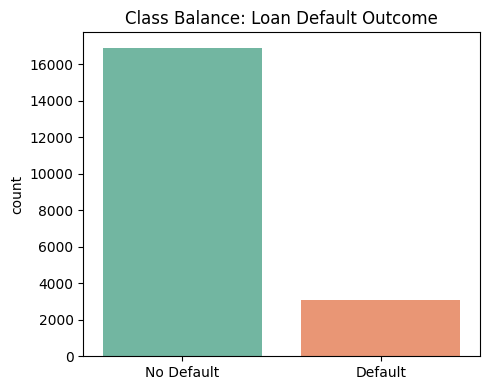

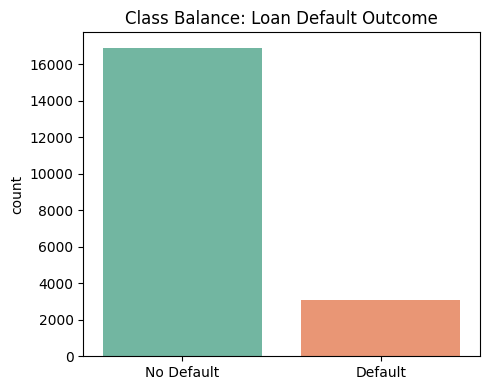

In [171]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="defaulted", hue="defaulted", palette="Set2", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Default", "Default"])
ax.set_title("Class Balance: Loan Default Outcome")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


The class distribution confirms that loan defaults are considerably less frequent than successful repayments.

Without appropriate handling, a predictive model may become biased toward the majority class, reducing its ability to correctly identify borrowers at risk of default.

## Relationship Analysis

Before engineering new features, the relationship between each predictor and loan default was explored. This step identifies variables that already contain predictive signal and helps guide feature engineering rather than creating features blindly.

###Numeric correlations

In [172]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Correlation with target
corr_with_target = (
    corr_matrix['defaulted']
    .sort_values(ascending=False)
)

corr_with_target

,defaulted
defaulted,1.000000
loan_amount_ngn,0.122264
existing_loans_count,0.061053
interest_rate_monthly_pct,0.006766
age,0.000851
monthly_income_ngn,-0.001273
mobile_money_active,-0.005761
pos_txn_volume_ngn_monthly,-0.030064
has_bank_account,-0.030408
sim_tenure_months,-0.033783


,defaulted
defaulted,1.000000
loan_amount_ngn,0.122264
existing_loans_count,0.061053
interest_rate_monthly_pct,0.006766
age,0.000851
monthly_income_ngn,-0.001273
mobile_money_active,-0.005761
pos_txn_volume_ngn_monthly,-0.030064
has_bank_account,-0.030408
sim_tenure_months,-0.033783


Loan tenor shows the strongest relationship with default (-0.25), suggesting borrowers with longer repayment periods tend to default less frequently in this synthetic dataset. Repayment history score also shows a meaningful negative relationship, confirming that stronger repayment behavior reduces default risk. Loan amount exhibits the strongest positive relationship, indicating larger loans are associated with slightly higher default likelihood.

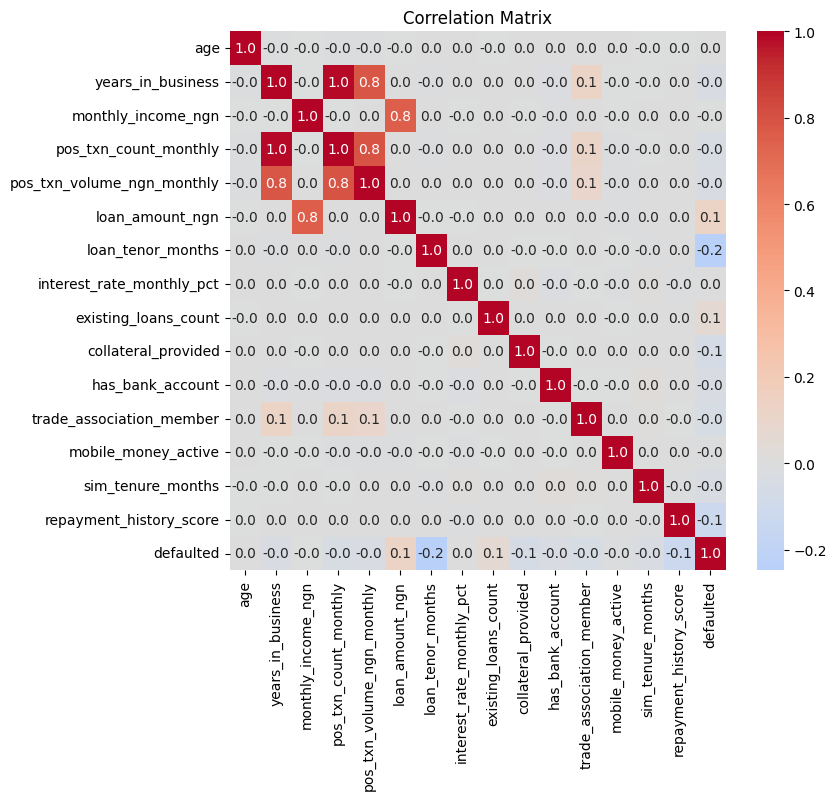

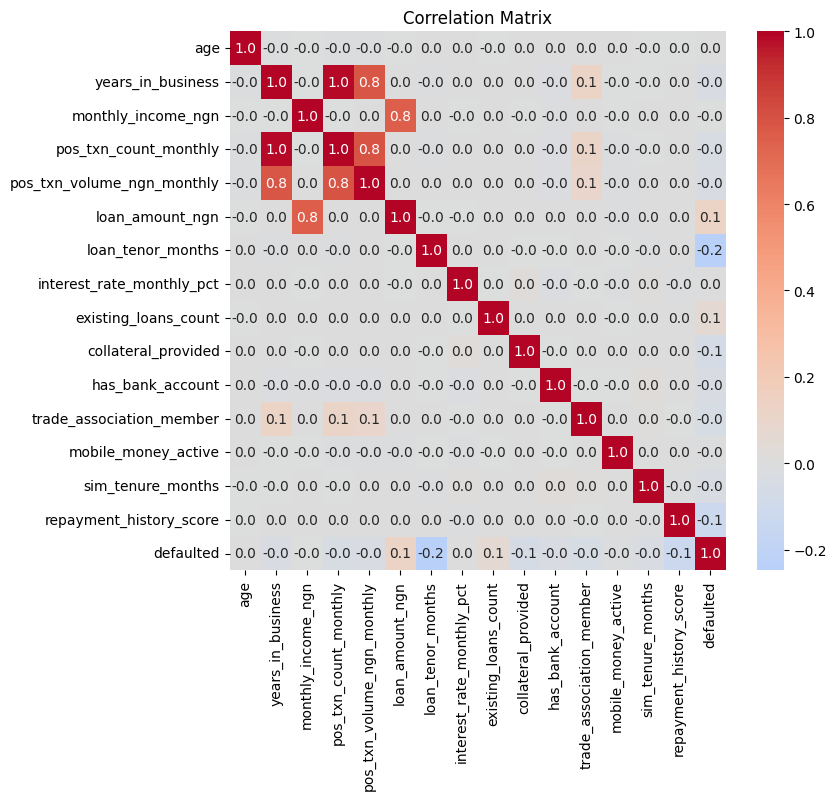

In [94]:
plt.figure(figsize=(8,7))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt='.1f',
    center=0
)
plt.title("Correlation Matrix")
plt.show()

The correlation matrix reveals that multicollinearity among numeric variables is generally low, meaning most predictors contribute distinct information to the model.
While a few variables such as `years_in_business`, `monthly_income_ngn`, `pos_txn_count_monthly`, and `pos_txn_volume_ngn_monthly` show moderate positive correlations (≈ 0.8–1.0), the majority of relationships hover near zero.

### Categorical Default Rates

####Default Rates To Gender

In [95]:
default_rate_gender = (
    df.groupby('gender')['defaulted']
      .mean()
      .sort_values())
default_rate_gender

,defaulted
gender,
Female,0.149726
Male,0.158776


,defaulted
gender,
Female,0.149726
Male,0.158776


Default rates are nearly identical across genders (15.0% vs. 15.9%), suggesting gender alone provides little discriminatory power for predicting loan default.

Text(0.5, 1.0, 'Loan Default Rate by Gender')

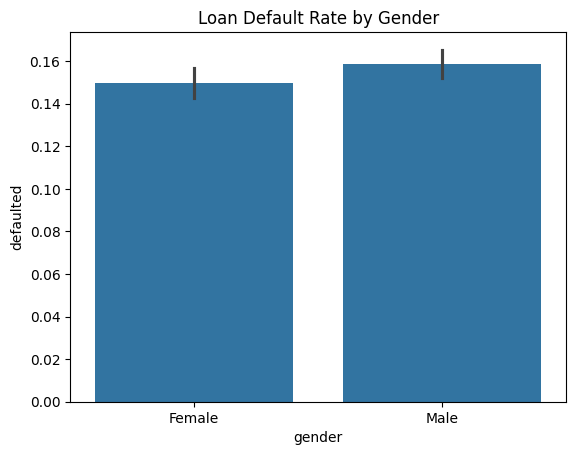

Text(0.5, 1.0, 'Loan Default Rate by Gender')

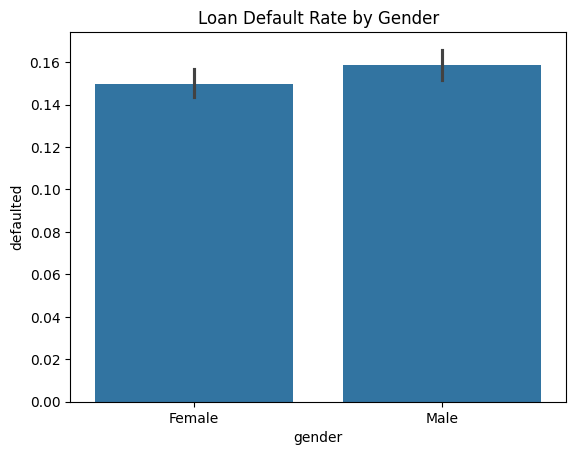

In [96]:
sns.barplot(
    data=df,
    x='gender',
    y='defaulted'
)

plt.title("Loan Default Rate by Gender")

####Default Rates To State

In [97]:
default_rate_state = (
    df.groupby('state')['defaulted']
      .mean()
      .sort_values()
)

default_rate_state

,defaulted
state,
Rivers,0.140545
Kano,0.147137
Kwara,0.148096
Enugu,0.148863
Plateau,0.149243
Osun,0.150983
Delta,0.151367
Anambra,0.156820
Lagos,0.157970


,defaulted
state,
Rivers,0.140545
Kano,0.147137
Kwara,0.148096
Enugu,0.148863
Plateau,0.149243
Osun,0.150983
Delta,0.151367
Anambra,0.156820
Lagos,0.157970


Default rates vary modestly across states, ranging from approximately 14.1% in Rivers to 16.5% in Oyo. While geographic differences exist, the variation is relatively small, suggesting location alone is unlikely to be a dominant predictor.

####Default Rates To Different Business Sectors

In [98]:
default_rate_business_sector = (
    df.groupby('business_sector')['defaulted']
      .mean()
      .sort_values()
)

default_rate_business_sector

,defaulted
business_sector,
Food & Provisions,0.145201
Artisan/Repairs,0.149842
Transport/Logistics,0.153631
Agriculture,0.154034
Electronics/Phone Accessories,0.156641
Services (Salon/Barbing etc.),0.157097
Trading/Retail,0.158893
Fashion & Tailoring,0.159545


,defaulted
business_sector,
Food & Provisions,0.145201
Artisan/Repairs,0.149842
Transport/Logistics,0.153631
Agriculture,0.154034
Electronics/Phone Accessories,0.156641
Services (Salon/Barbing etc.),0.157097
Trading/Retail,0.158893
Fashion & Tailoring,0.159545


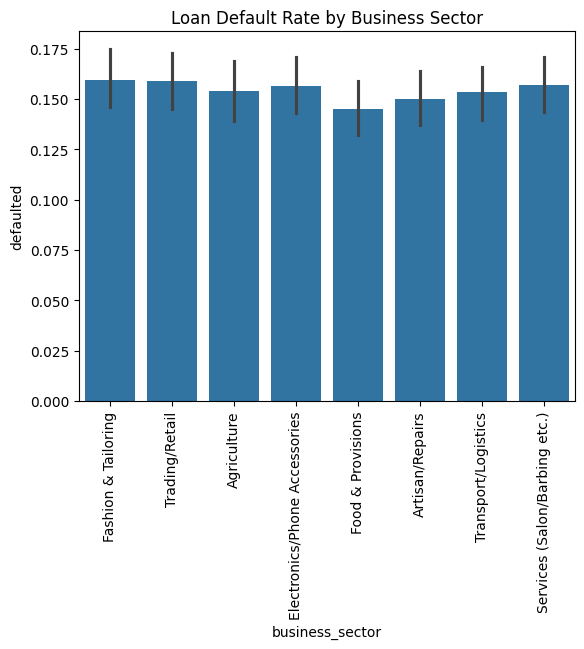

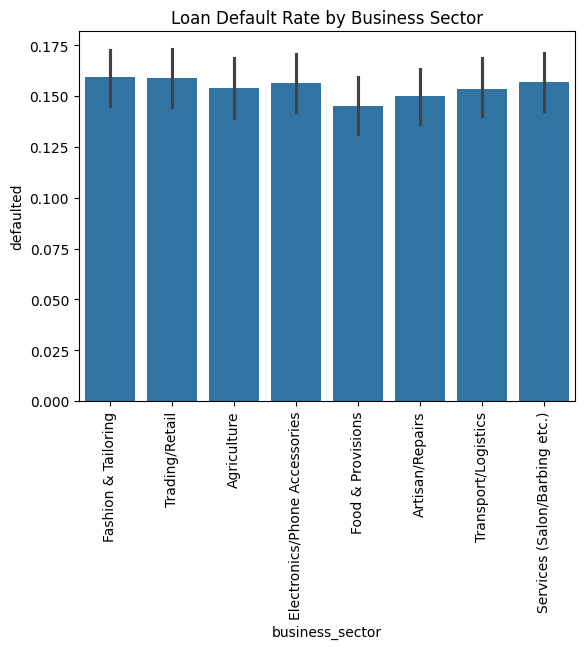

In [99]:
sns.barplot(
    data=df,
    x='business_sector',
    y='defaulted'
)
plt.title("Loan Default Rate by Business Sector")
plt.xticks(rotation=90)
plt.show()


Loan default varies slightly across business sectors, with Food & Provisions recording the lowest default rate and Fashion & Tailoring the highest. However, the narrow spread indicates business sector is likely a supporting rather than primary predictor.

####Default Rates To Loan channel

In [100]:
default_rate_loan_channel = (
    df.groupby('loan_channel')['defaulted']
      .mean()
      .sort_values()
)

default_rate_loan_channel

,defaulted
loan_channel,
Cooperative (Esusu/Ajo),0.149214
Mobile App,0.154218
Bank Branch,0.155715
POS Agent,0.155812


,defaulted
loan_channel,
Cooperative (Esusu/Ajo),0.149214
Mobile App,0.154218
Bank Branch,0.155715
POS Agent,0.155812


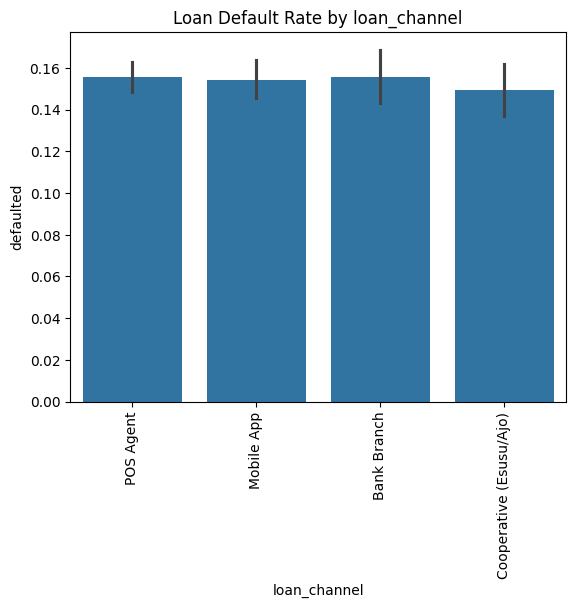

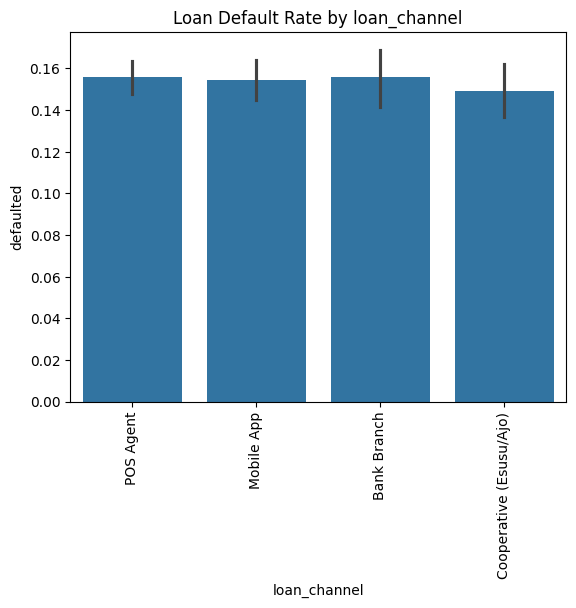

In [101]:
sns.barplot(
    data=df,
    x='loan_channel',
    y='defaulted'
)
plt.title("Loan Default Rate by loan_channel")
plt.xticks(rotation=90)
plt.show()

Default rates remain consistent across loan acquisition channels, suggesting that the method used to obtain a loan contributes little additional predictive value on its own.

####Default Rates To Urban and Rural Settlement

In [102]:
default_rate_urban_rural = (
    df.groupby('urban_rural')['defaulted']
      .mean()
      .sort_values()
)

default_rate_urban_rural

,defaulted
urban_rural,
Urban,0.153285
Rural,0.156832


,defaulted
urban_rural,
Urban,0.153285
Rural,0.156832


Text(0.5, 1.0, 'Loan Default Rate by urban_rural')

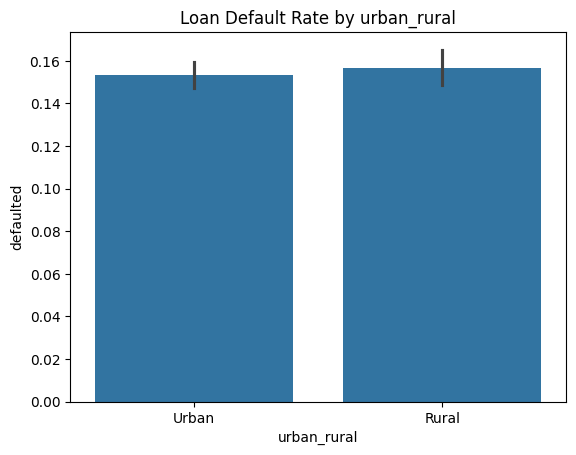

Text(0.5, 1.0, 'Loan Default Rate by urban_rural')

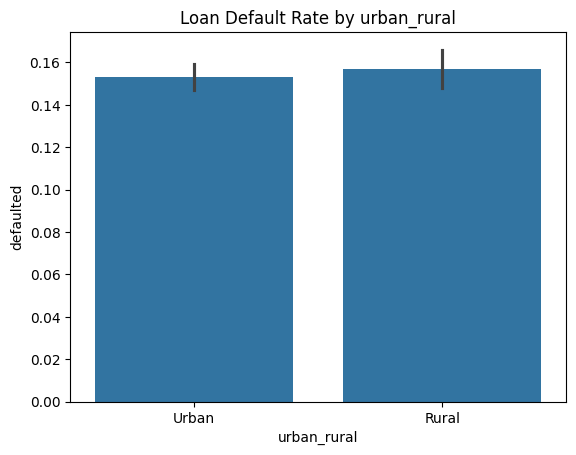

In [103]:
sns.barplot(
    data=df,
    x='urban_rural',
    y='defaulted'
)
plt.title("Loan Default Rate by urban_rural")

Urban and rural borrowers exhibit nearly identical default rates, indicating that location type alone is unlikely to meaningfully distinguish high-risk borrowers.

### Distribution Comparisons

<Axes: xlabel='defaulted', ylabel='monthly_income_ngn'>

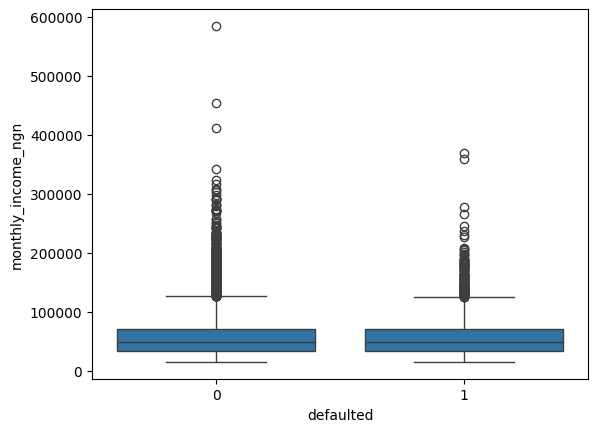

<Axes: xlabel='defaulted', ylabel='monthly_income_ngn'>

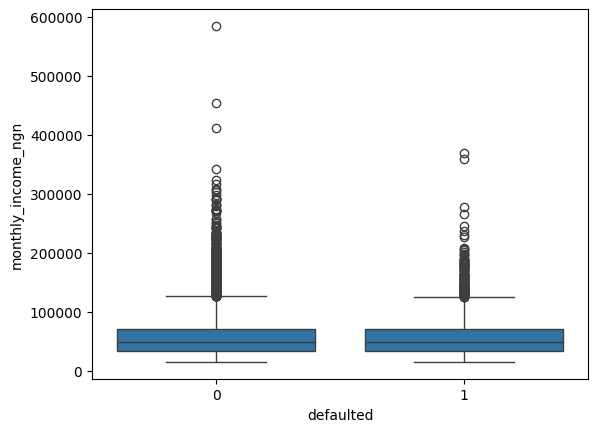

In [104]:
sns.boxplot(
    data=df,
    x='defaulted',
    y='monthly_income_ngn'
)

The boxplot shows that monthly income distributions overlap substantially between borrowers who defaulted (1) and those who did not (0).
Both groups exhibit similar median income levels and comparable spreads, with numerous high‑income outliers in each category.

This pattern indicates that income alone is unlikely to distinguish high‑risk borrowers, as default behavior does not vary meaningfully across income levels.
It suggests that repayment history, loan terms, or behavioral factors may provide stronger predictive signals for default risk than income

<Axes: xlabel='loan_amount_ngn', ylabel='Count'>

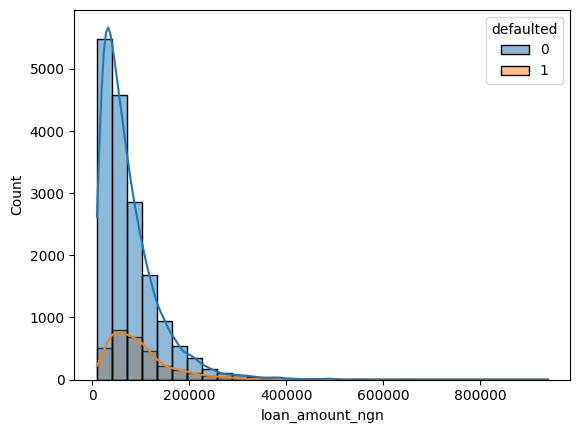

<Axes: xlabel='loan_amount_ngn', ylabel='Count'>

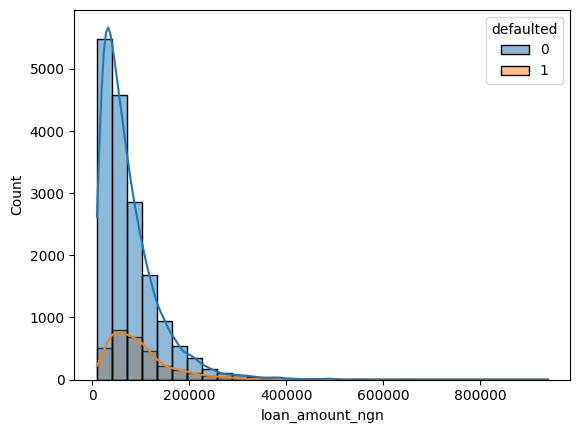

In [105]:
sns.histplot(
    data=df,
    x='loan_amount_ngn',
    hue='defaulted',
    kde=True,
    bins=30
)

The histogram illustrates that borrowers who default tend to receive slightly larger loans compared to those who repay successfully.
Although the distributions for defaulted and non‑defaulted borrowers overlap considerably, the defaulted group shows a broader spread toward higher loan amounts, suggesting that loan size may influence repayment outcomes.

This pattern implies that loan amount carries useful predictive information while not decisive on its own, it could become more influential when combined with other borrower characteristics such as income, tenure, or repayment history.

#Feature Engineering

Looking at the dataset, there is plenty of opportunity to create features that mimic how Nigerian lenders think about risk. Right now, many of the variables are "raw." Models often perform better when you transform them into features that capture borrower behavior.

so before, we get into engineering, I want to paint a picture in our minds

`Imagine you're a Nigerian micro-lender.
Would you approve a loan simply because someone earns ₦60,000/month?`

Probably not, you would ask questions like:

-  How large is the loan relative to their income?
-  Have they borrowed before?
-  How long have they been running their business?
- Are they active in business transactions?
- How good is their repayment history?
- Do they have collateral?
- Do they have multiple existing loans?

These questions translate directly into the following engineered features.

## **Feature #1:**  Loan-to-Income Ratio

In [106]:
df["loan_income_ratio"] = (
    df["loan_amount_ngn"] /
    df["monthly_income_ngn"]
)


`Loan-to-income ratio` measures the size of a borrower's loan relative to their monthly income. Higher values indicate greater repayment burden and are expected to be associated with increased default risk.

## **Feature #2:** POS Transaction Value per Transaction

In [107]:
df["avg_pos_transaction"] = (
    df["pos_txn_volume_ngn_monthly"] /
    (df["pos_txn_count_monthly"] + 1)
)

Average POS transaction value estimates the typical value of each business transaction. It provides additional insight into business activity beyond total transaction volume.

`Note:` the +1 prevents division by zero

## **Feature #3:** Business Stability

In [108]:
df["income_per_year_business"] = (
    df["monthly_income_ngn"] /
    (df["years_in_business"] + 1)
)

Not perfect, but it captures
"How much income does this business generate considering its maturity?"

## **Feature #4:** Debt Burden

In [109]:
df["debt_burden"] = (
    df["existing_loans_count"] *
    df["loan_amount_ngn"]
)

Borrowers with several existing loans requesting another loan may represent higher risk.

## **Feature #5:** Financial Inclusion Score

In [110]:
df["financial_inclusion_score"] = (
    df["has_bank_account"] +
    df["mobile_money_active"] +
    df["trade_association_member"]
)

Financial inclusion score combines access to formal financial services and participation in business networks. Borrowers with higher scores may have stronger financial engagement and potentially lower lending risk.

## **Feature #6:** Business Activity`

In [111]:
df["business_activity_score"] = (
    df["pos_txn_count_monthly"] *
    df["years_in_business"]
)

Someone operating 8 years with 150 monthly transactions is likely more stable than 0.5 years with 8 transactions.

## **Feature #7:** Trade Association + Years

In [112]:
df["business_network_score"] = (
    df["trade_association_member"] *
    df["years_in_business"]
)

Someone in an association for six years may be a safer borrower than someone who joined recently.

## **Feature #8:** Age Group

In [113]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18,30,45,60,70],
    labels=[
        "Young",
        "Adult",
        "Middle",
        "Senior"
    ]
)

In [114]:
df['age_group'].value_counts()

,count
age_group,
Adult,6326
Middle,6160
Young,5048
Senior,2052


,count
age_group,
Adult,6326
Middle,6160
Young,5048
Senior,2052


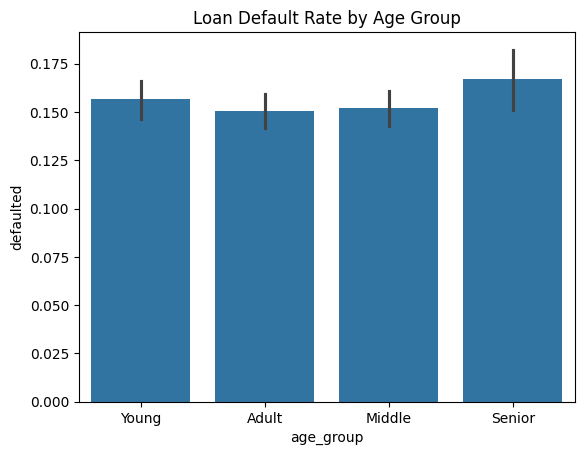

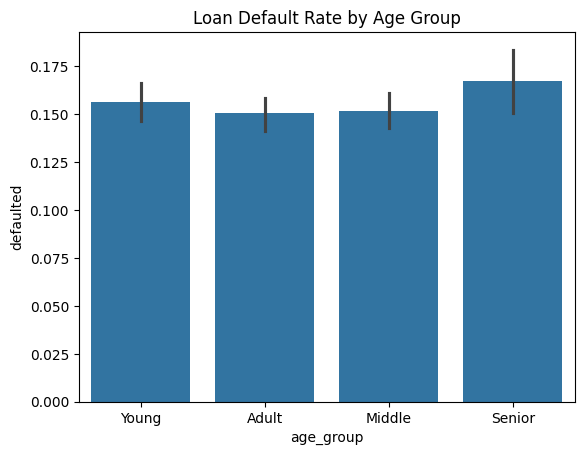

In [115]:
sns.barplot(
    data=df,
    x="age_group",
    y="defaulted"
)

plt.title("Loan Default Rate by Age Group")
plt.show()

In [116]:
default_rate_age = (
    df.groupby("age_group", observed=False)["defaulted"]
      .mean()
      .sort_values()
)

default_rate_age

,defaulted
age_group,
Adult,0.150490
Middle,0.151948
Young,0.156498
Senior,0.167154


,defaulted
age_group,
Adult,0.150490
Middle,0.151948
Young,0.156498
Senior,0.167154


Although the differences are modest, default rates increase gradually across age groups, with Senior borrowers recording the highest default rate (16.7%) compared with Adults (15.0%). This suggests that borrower age may contribute incremental predictive information when combined with other financial and behavioral features, so the engineered age_group feature was retained for modeling.

In [117]:
engineered_features = [
    "loan_income_ratio",
    "avg_pos_transaction",
    "income_per_year_business",
    "debt_burden",
    "financial_inclusion_score",
    "business_activity_score",
    "business_network_score",

]

df[engineered_features].describe()

,loan_income_ratio,avg_pos_transaction,income_per_year_business,debt_burden,financial_inclusion_score,business_activity_score,business_network_score
count,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000
mean,1.401818,3294.029456,14412.814510,6.297505e+04,1.739900,437.001795,1.668010
std,0.632946,1473.170084,13506.182735,1.040127e+05,0.795474,674.789631,3.081917
min,0.291971,0.000000,852.272727,0.000000e+00,0.000000,0.000000,0.000000
25%,0.853270,2010.651515,6131.093544,0.000000e+00,1.000000,66.500000,0.000000
50%,1.394910,3280.157480,10422.474502,2.400000e+04,2.000000,201.300000,0.000000
75%,1.951972,4573.356310,18000.000000,8.900000e+04,2.000000,524.400000,2.500000
max,2.511013,5959.210526,190666.666667,2.004000e+06,3.000000,9700.000000,25.000000


,loan_income_ratio,avg_pos_transaction,income_per_year_business,debt_burden,financial_inclusion_score,business_activity_score,business_network_score
count,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000
mean,1.401818,3294.029456,14412.814510,6.297505e+04,1.739900,437.001795,1.668010
std,0.632946,1473.170084,13506.182735,1.040127e+05,0.795474,674.789631,3.081917
min,0.291971,0.000000,852.272727,0.000000e+00,0.000000,0.000000,0.000000
25%,0.853270,2010.651515,6131.093544,0.000000e+00,1.000000,66.500000,0.000000
50%,1.394910,3280.157480,10422.474502,2.400000e+04,2.000000,201.300000,0.000000
75%,1.951972,4573.356310,18000.000000,8.900000e+04,2.000000,524.400000,2.500000
max,2.511013,5959.210526,190666.666667,2.004000e+06,3.000000,9700.000000,25.000000


In [118]:
corr = (
    df[engineered_features + ["defaulted"]]
    .corr()["defaulted"]
    .sort_values(ascending=False)
)

corr

,defaulted
defaulted,1.000000
loan_income_ratio,0.218935
debt_burden,0.105404
income_per_year_business,0.018802
avg_pos_transaction,-0.000392
business_activity_score,-0.034763
business_network_score,-0.047146
financial_inclusion_score,-0.048502


,defaulted
defaulted,1.000000
loan_income_ratio,0.218935
debt_burden,0.105404
income_per_year_business,0.018802
avg_pos_transaction,-0.000392
business_activity_score,-0.034763
business_network_score,-0.047146
financial_inclusion_score,-0.048502


Feature engineering strengthened the predictive signal of several variables. Most notably, the loan-to-income ratio increased its correlation with loan default from 0.12 (loan amount alone) to 0.22, suggesting that repayment burden is a more informative indicator of default risk than loan size in isolation. These engineered features will be carried forward into the modeling stage.

#Feature Selection

In [119]:
TARGET = "defaulted"
RANDOM_STATE = 42

NUMERIC_FEATURES = [
    "years_in_business", "monthly_income_ngn", "pos_txn_count_monthly",
    "pos_txn_volume_ngn_monthly", "loan_amount_ngn", "loan_tenor_months",
    "interest_rate_monthly_pct", "existing_loans_count", "sim_tenure_months",
    "repayment_history_score",    "loan_income_ratio","avg_pos_transaction","income_per_year_business",
    "debt_burden", "financial_inclusion_score","business_activity_score", "business_network_score",
]
BINARY_FEATURES = ["collateral_provided", "has_bank_account", "trade_association_member", "mobile_money_active"]
CATEGORICAL_FEATURES = ["age_group","gender", "state", "business_sector", "urban_rural", "loan_channel"]
ALL_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

X = df[ALL_FEATURES]
y = df[TARGET]

The final feature set combines borrower demographics, financial information, business characteristics, and engineered risk indicators to predict loan default. Unique identifiers and the target variable were excluded from the predictors to prevent data leakage. Features were grouped into numerical, binary, and categorical variables to support an efficient preprocessing pipeline and ensure each data type receives the appropriate transformation before model training.

# Train/Test Split

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.2%} | Test default rate: {y_test.mean():.2%}")


Train: (16000, 27), Test: (4000, 27)
Train default rate: 15.44% | Test default rate: 15.45%
Train: (16000, 27), Test: (4000, 27)
Train default rate: 15.44% | Test default rate: 15.45%


The dataset was divided into training (80%), 16000 entries and testing (20%) sets with 4000 data entries using stratified sampling to preserve the original class distribution.

The default rate remained virtually identical in both sets (15.44% vs. 15.45%), confirming that the split preserved the target distribution.
Useful because the model evaluation reflects real-world borrower behavior and provides an unbiased estimate of predictive performance.

# Preprocessing

In [121]:
def build_preprocessor():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", numeric_pipeline, NUMERIC_FEATURES),
        ("bin", "passthrough", BINARY_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ])


A preprocessing pipeline was created to automate data preparation before model training. Numerical variables were imputed using the median and standardized, while categorical variables were imputed using the most frequent category and transformed through one-hot encoding. Binary variables were retained without modification. Using a unified preprocessing pipeline ensures consistent transformations across both training and unseen data while reducing the risk of data leakage.

# Model Training

Three models are trained for comparison:
- **Logistic Regression** — interpretable linear baseline
- **Random Forest** — non-linear, robust baseline
- **XGBoost** — stronger gradient-boosted model, typically the best performer on tabular data

## Baseline Model - Experiment 1


The first set of models will be trained using the original class distribution without applying any imbalance handling techniques. Establishing this baseline provides a reference point for evaluating whether methods such as class weighting or SMOTE lead to meaningful improvements in identifying high-risk borrowers.

### Logistic Regression Model

Logistic Regression serves as the baseline classifier due to its simplicity, interpretability, and widespread use in credit risk modeling. It estimates the probability of loan default based on a linear combination of borrower characteristics and provides a strong benchmark against which more complex models can be compared.

In [122]:
logistic_pipeline = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("classifier", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

### Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees to capture complex nonlinear relationships between borrower characteristics and repayment outcomes. Compared with Logistic Regression, it is better suited for detecting interactions among financial and behavioral features.

In [123]:
rf_pipeline = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    ))
])

### XGBoost

XGBoost is a gradient boosting algorithm capable of learning complex nonlinear decision boundaries. The baseline model is trained using the original class distribution without imbalance adjustments to establish a fair performance benchmark before applying class-weighting techniques.

In [124]:
xgb_pipeline = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("classifier", XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5
    ))
])



## Class Weighting - Experiment 2



The baseline models showed high overall accuracy but relatively low recall for the default class, indicating that many high-risk borrowers were still being misclassified as low risk.

To improve the model's ability to identify loan defaults, class weighting was introduced. This approach assigns greater importance to the minority class during training, encouraging the algorithms to pay more attention to defaulted borrowers without altering the original dataset.

### Logistic Regression

In [125]:
lr_weighted_pipeline = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("classifier", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        class_weight="balanced"
    ))
])

### Random Forest

In [126]:
rf_weighted_pipeline = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

### XGBoost

In [127]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight (for XGBoost) = {scale_pos_weight:.2f}")


scale_pos_weight (for XGBoost) = 5.48
scale_pos_weight (for XGBoost) = 5.48


In [128]:
xgb_weighted_pipeline = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("classifier", XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        scale_pos_weight=scale_pos_weight
    ))
])

## SMOTE Oversampling - Experiment 3



Although class weighting improved the models' ability to identify defaulting borrowers, it does not change the underlying class distribution. The minority class remains underrepresented during training.

To further address this imbalance, the Synthetic Minority Oversampling Technique (SMOTE) is applied. Rather than duplicating existing minority observations, SMOTE generates synthetic examples by interpolating between similar minority-class samples. This provides the models with more representative default cases while preserving the original test set for unbiased evaluation.

The objective of this experiment is to determine whether balancing the training data leads to improved Recall and F1-score without causing excessive false positives.

In [129]:
# Reusing previous random state.
smote = SMOTE(
    random_state=RANDOM_STATE
)

### Logistic Regression + SMOTE

In [130]:
lr_smote_pipeline = ImbPipeline([
    ("preprocessor", build_preprocessor()),
    ("smote", smote),
    ("classifier", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

### Random Forest + SMOTE

In [131]:
rf_smote_pipeline = ImbPipeline([
    ("preprocessor", build_preprocessor()),
    ("smote", smote),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    ))
])


### XGBoost + SMOTE

In [132]:
xgb_smote_pipeline = ImbPipeline([
    ("preprocessor", build_preprocessor()),
    ("smote", smote),
    ("classifier", XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5
    ))
])

# Model Evaluation

In [133]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:,1]
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC_AUC": roc_auc_score(y_test, probabilities),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    }


    print("="*60)
    print(name)
    print("="*60)

    print(classification_report(y_test, predictions))

    # Confusion Matrix
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    return results

## Baseline Model

### Logistic Regression Model

Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.99      0.92      3382
           1       0.76      0.18      0.29       618

    accuracy                           0.86      4000
   macro avg       0.82      0.58      0.61      4000
weighted avg       0.85      0.86      0.83      4000



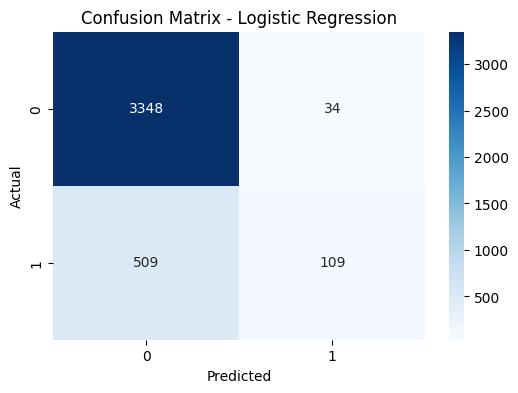

Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.99      0.92      3382
           1       0.76      0.18      0.29       618

    accuracy                           0.86      4000
   macro avg       0.82      0.58      0.61      4000
weighted avg       0.85      0.86      0.83      4000



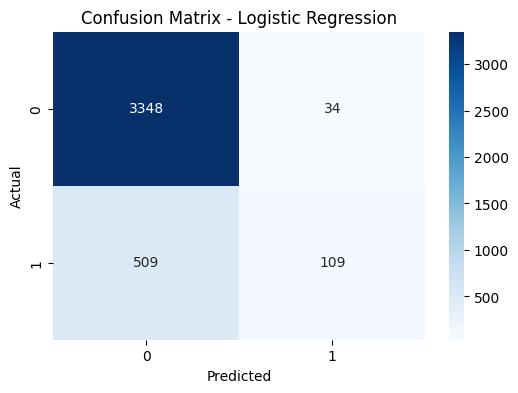

In [134]:
lr_results = evaluate_model(
    "Logistic Regression",
    logistic_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

### Random Forest Model

Random Forest
              precision    recall  f1-score   support

           0       0.88      0.99      0.93      3382
           1       0.79      0.28      0.41       618

    accuracy                           0.88      4000
   macro avg       0.83      0.63      0.67      4000
weighted avg       0.87      0.88      0.85      4000



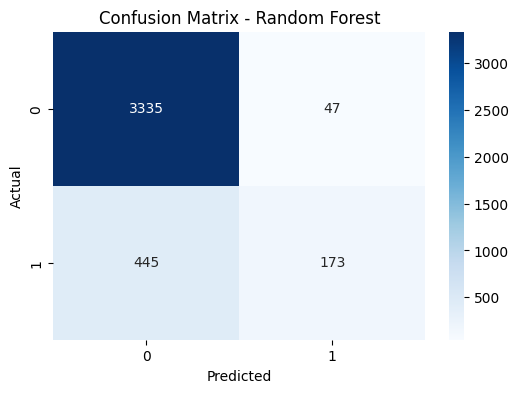

Random Forest
              precision    recall  f1-score   support

           0       0.88      0.99      0.93      3382
           1       0.79      0.28      0.41       618

    accuracy                           0.88      4000
   macro avg       0.83      0.63      0.67      4000
weighted avg       0.87      0.88      0.85      4000



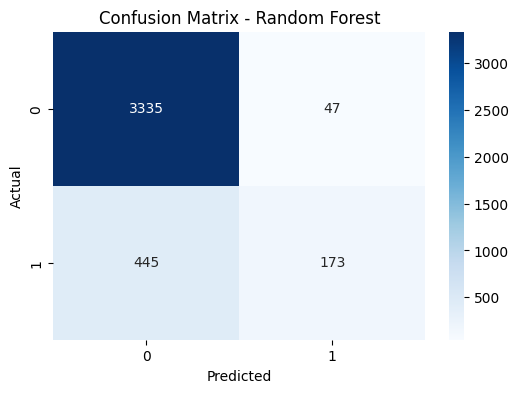

In [135]:
rf_results = evaluate_model(
    "Random Forest",
    rf_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

### XGBoost

XGBoost
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      3382
           1       0.73      0.34      0.46       618

    accuracy                           0.88      4000
   macro avg       0.81      0.66      0.70      4000
weighted avg       0.86      0.88      0.86      4000



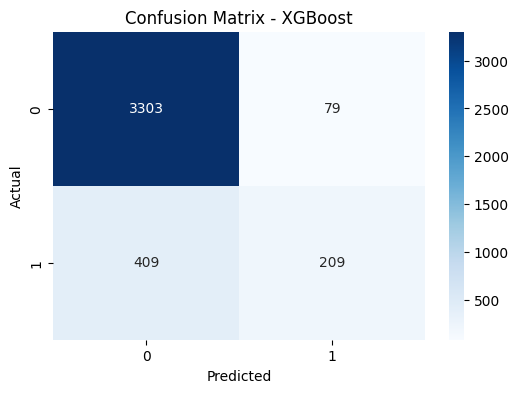

XGBoost
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      3382
           1       0.73      0.34      0.46       618

    accuracy                           0.88      4000
   macro avg       0.81      0.66      0.70      4000
weighted avg       0.86      0.88      0.86      4000



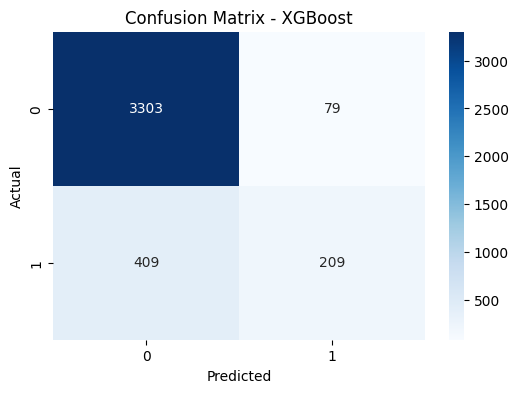

In [136]:
xgb_results = evaluate_model(
    "XGBoost",
    xgb_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

Despite achieving approximately 88% accuracy, the models correctly identified only 18–34% of borrowers who eventually defaulted. Since identifying high-risk borrowers is the primary business objective, Recall and F1-score provide a more meaningful assessment than overall Accuracy.

### Baseline Model Comparison Table

In [137]:
baseline_results = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results
])

baseline_results.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,TP,FP,FN,TN
2,XGBoost,0.87800,0.725694,0.338188,0.461369,0.809548,209,79,409,3303
1,Random Forest,0.87700,0.786364,0.279935,0.412888,0.796722,173,47,445,3335
0,Logistic Regression,0.86425,0.762238,0.176375,0.286465,0.794572,109,34,509,3348


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,TP,FP,FN,TN
2,XGBoost,0.87800,0.725694,0.338188,0.461369,0.809548,209,79,409,3303
1,Random Forest,0.87700,0.786364,0.279935,0.412888,0.796722,173,47,445,3335
0,Logistic Regression,0.86425,0.762238,0.176375,0.286465,0.794572,109,34,509,3348


Although all three baseline models achieved high overall accuracy (86–88%), this metric is influenced by the class imbalance, where non-default cases dominate the dataset. Model comparison therefore focuses on Recall, F1-score, and ROC-AUC, which better reflect the ability to identify high-risk borrowers. Among the baseline models, XGBoost achieved the highest Recall (34%) and F1-score (0.46), making it the strongest candidate for further improvement through imbalance handling.




## Class Weighting

Rather than focusing solely on overall accuracy, this experiment evaluates whether assigning greater importance to the minority class improves the identification of defaulting borrowers. The primary metric of interest is recall for the default class, as missing a high-risk borrower is generally more costly than incorrectly flagging a low-risk borrower.

The results will be compared against the baseline models to determine whether cost-sensitive learning provides a better balance between detecting defaults and maintaining acceptable precision.

### Logistic Regression

Logistic Regression (Class Weight)
              precision    recall  f1-score   support

           0       0.93      0.71      0.81      3382
           1       0.32      0.72      0.44       618

    accuracy                           0.71      4000
   macro avg       0.62      0.72      0.62      4000
weighted avg       0.84      0.71      0.75      4000



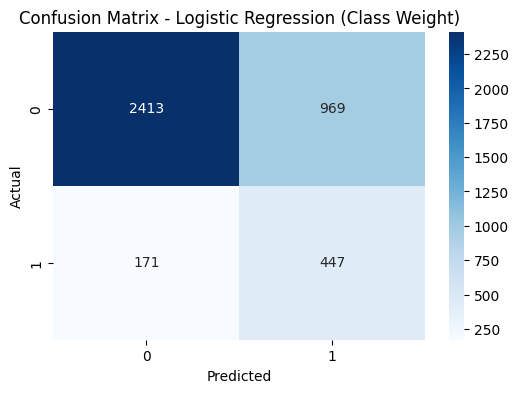

Logistic Regression (Class Weight)
              precision    recall  f1-score   support

           0       0.93      0.71      0.81      3382
           1       0.32      0.72      0.44       618

    accuracy                           0.71      4000
   macro avg       0.62      0.72      0.62      4000
weighted avg       0.84      0.71      0.75      4000



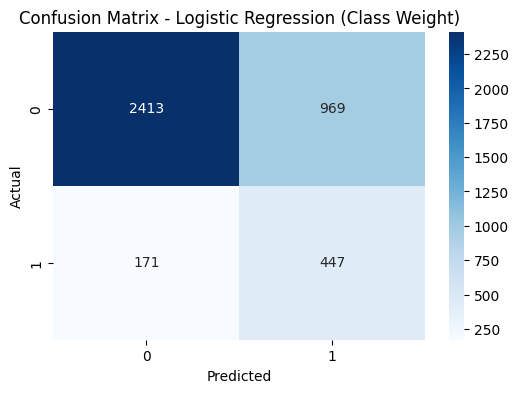

In [138]:
lr_weighted_results = evaluate_model(
    "Logistic Regression (Class Weight)",
    lr_weighted_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

### Random Forest

Random Forest (Class Weight)
              precision    recall  f1-score   support

           0       0.88      0.99      0.93      3382
           1       0.79      0.24      0.37       618

    accuracy                           0.87      4000
   macro avg       0.83      0.62      0.65      4000
weighted avg       0.86      0.87      0.84      4000



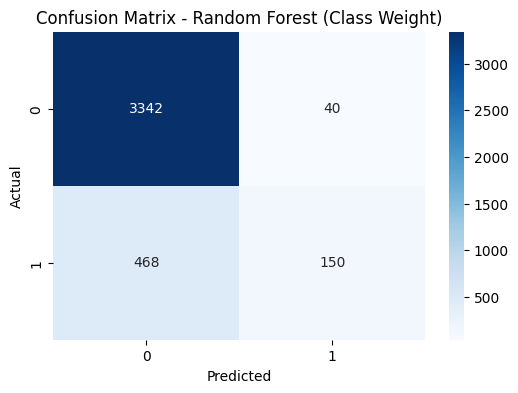

Random Forest (Class Weight)
              precision    recall  f1-score   support

           0       0.88      0.99      0.93      3382
           1       0.79      0.24      0.37       618

    accuracy                           0.87      4000
   macro avg       0.83      0.62      0.65      4000
weighted avg       0.86      0.87      0.84      4000



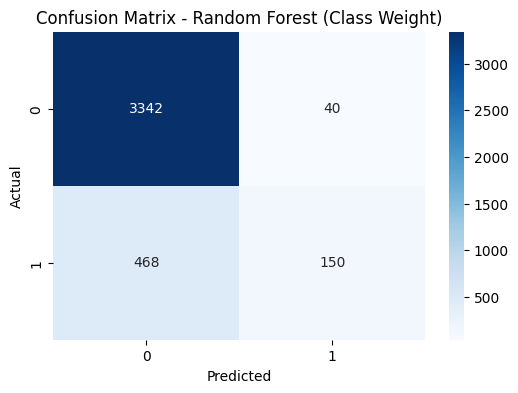

In [139]:
rf_weighted_results = evaluate_model(
    "Random Forest (Class Weight)",
    rf_weighted_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

### XGBoost

XGBoost (Class Weight)
              precision    recall  f1-score   support

           0       0.92      0.85      0.89      3382
           1       0.43      0.62      0.51       618

    accuracy                           0.82      4000
   macro avg       0.68      0.74      0.70      4000
weighted avg       0.85      0.82      0.83      4000



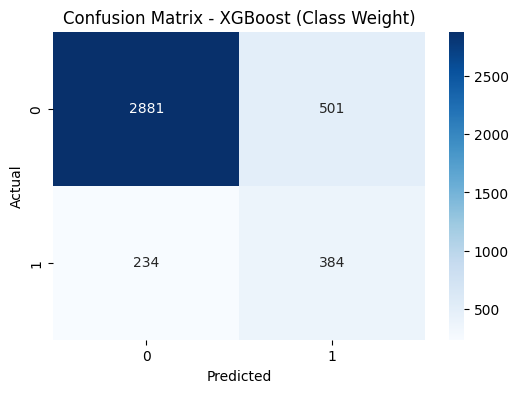

XGBoost (Class Weight)
              precision    recall  f1-score   support

           0       0.92      0.85      0.89      3382
           1       0.43      0.62      0.51       618

    accuracy                           0.82      4000
   macro avg       0.68      0.74      0.70      4000
weighted avg       0.85      0.82      0.83      4000



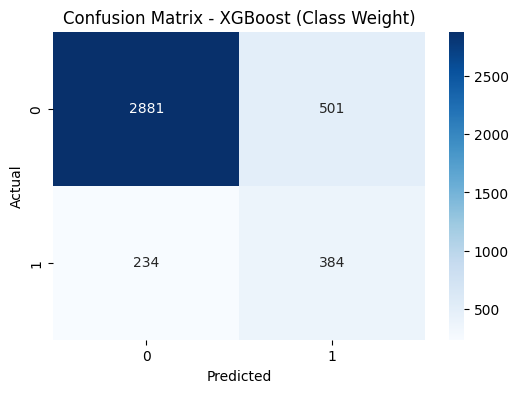

In [140]:
xgb_weighted_results = evaluate_model(
    "XGBoost (Class Weight)",
    xgb_weighted_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

### Compare Baseline vs Weighted

In [141]:
weighted_results = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results,
    lr_weighted_results,
    rf_weighted_results,
    xgb_weighted_results
])

weighted_results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,TP,FP,FN,TN
0,Logistic Regression,0.864,0.762,0.176,0.286,0.795,109,34,509,3348
1,Random Forest,0.877,0.786,0.280,0.413,0.797,173,47,445,3335
2,XGBoost,0.878,0.726,0.338,0.461,0.810,209,79,409,3303
3,Logistic Regression (Class Weight),0.715,0.316,0.723,0.440,0.791,447,969,171,2413
4,Random Forest (Class Weight),0.873,0.789,0.243,0.371,0.804,150,40,468,3342
5,XGBoost (Class Weight),0.816,0.434,0.621,0.511,0.807,384,501,234,2881


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,TP,FP,FN,TN
0,Logistic Regression,0.864,0.762,0.176,0.286,0.795,109,34,509,3348
1,Random Forest,0.877,0.786,0.280,0.413,0.797,173,47,445,3335
2,XGBoost,0.878,0.726,0.338,0.461,0.810,209,79,409,3303
3,Logistic Regression (Class Weight),0.715,0.316,0.723,0.440,0.791,447,969,171,2413
4,Random Forest (Class Weight),0.873,0.789,0.243,0.371,0.804,150,40,468,3342
5,XGBoost (Class Weight),0.816,0.434,0.621,0.511,0.807,384,501,234,2881


## SMOTE Oversampling Evaluation

### Logistic Regression + SMOTE

Logistic Regression (SMOTE)
              precision    recall  f1-score   support

           0       0.93      0.73      0.82      3382
           1       0.32      0.71      0.44       618

    accuracy                           0.72      4000
   macro avg       0.63      0.72      0.63      4000
weighted avg       0.84      0.72      0.76      4000



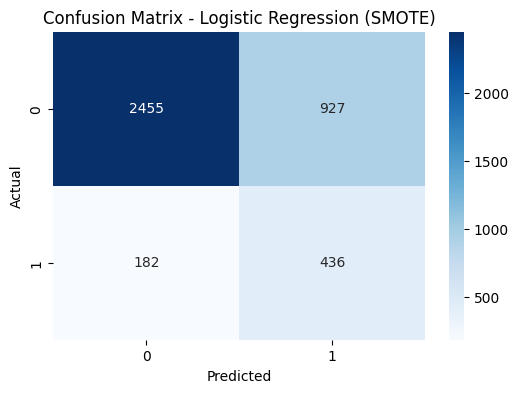

Logistic Regression (SMOTE)
              precision    recall  f1-score   support

           0       0.93      0.73      0.82      3382
           1       0.32      0.71      0.44       618

    accuracy                           0.72      4000
   macro avg       0.63      0.72      0.63      4000
weighted avg       0.84      0.72      0.76      4000



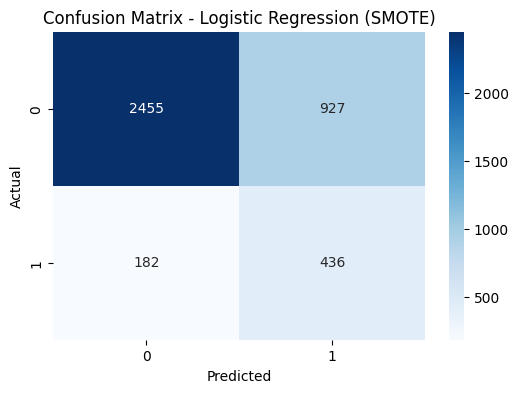

In [142]:
lr_smote_results = evaluate_model(
    "Logistic Regression (SMOTE)",
    lr_smote_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

### Random Forest + SMOTE

Random Forest (SMOTE)
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      3382
           1       0.69      0.35      0.47       618

    accuracy                           0.88      4000
   macro avg       0.79      0.66      0.70      4000
weighted avg       0.86      0.88      0.86      4000



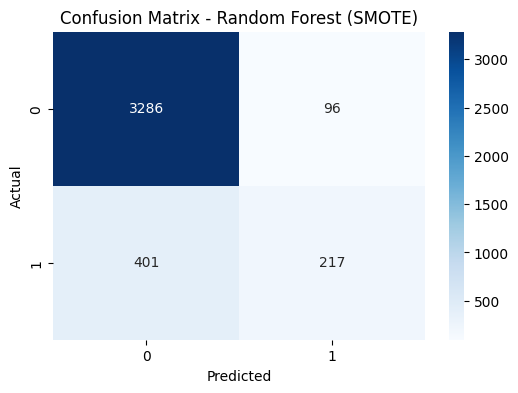

Random Forest (SMOTE)
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      3382
           1       0.69      0.35      0.47       618

    accuracy                           0.88      4000
   macro avg       0.79      0.66      0.70      4000
weighted avg       0.86      0.88      0.86      4000



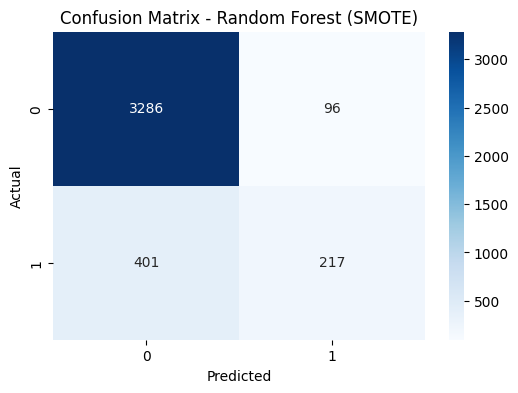

In [143]:
rf_smote_results = evaluate_model(
    "Random Forest (SMOTE)",
    rf_smote_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

### XGBoost + SMOTE

XGBoost (SMOTE)
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      3382
           1       0.71      0.36      0.48       618

    accuracy                           0.88      4000
   macro avg       0.80      0.67      0.70      4000
weighted avg       0.86      0.88      0.86      4000



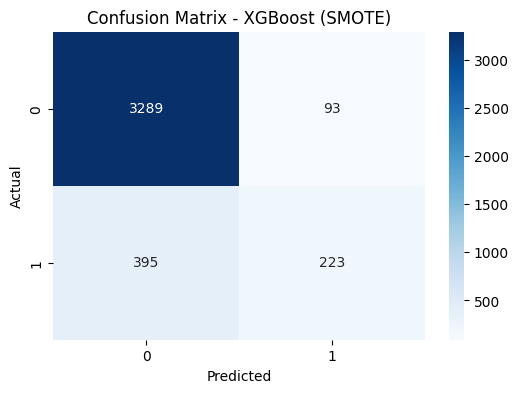

XGBoost (SMOTE)
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      3382
           1       0.71      0.36      0.48       618

    accuracy                           0.88      4000
   macro avg       0.80      0.67      0.70      4000
weighted avg       0.86      0.88      0.86      4000



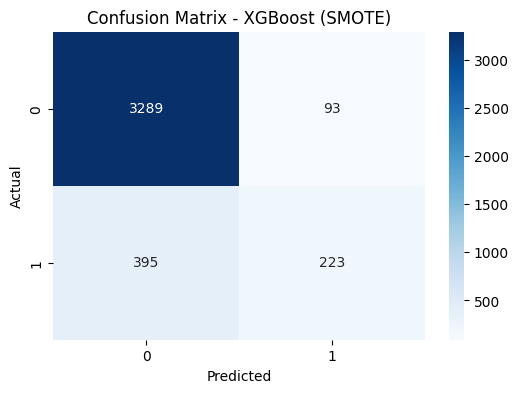

In [144]:
xgb_smote_results = evaluate_model(
    "XGBoost (SMOTE)",
    xgb_smote_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

Applying SMOTE produced mixed results across the three algorithms. Logistic Regression maintained a high recall (70.6%) comparable to class weighting but did not improve its F1-score and continued to generate a large number of false positives. Random Forest benefited most from SMOTE, improving both recall and F1-score compared with its baseline model. For XGBoost, SMOTE yielded only a marginal improvement over the baseline and remained inferior to the class-weighted version. These findings suggest that SMOTE was not universally beneficial for this dataset, likely because the class imbalance (approximately 15% defaults) was moderate rather than severe.

In [145]:
all_results = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results,
    lr_weighted_results,
    rf_weighted_results,
    xgb_weighted_results,
    lr_smote_results,
    rf_smote_results,
    xgb_smote_results
])

all_results.sort_values(
    by=["Recall", "F1"],
    ascending=False
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,TP,FP,FN,TN
3,Logistic Regression (Class Weight),0.715,0.316,0.723,0.440,0.791,447,969,171,2413
6,Logistic Regression (SMOTE),0.723,0.320,0.706,0.440,0.789,436,927,182,2455
5,XGBoost (Class Weight),0.816,0.434,0.621,0.511,0.807,384,501,234,2881
8,XGBoost (SMOTE),0.878,0.706,0.361,0.478,0.817,223,93,395,3289
7,Random Forest (SMOTE),0.876,0.693,0.351,0.466,0.801,217,96,401,3286
2,XGBoost,0.878,0.726,0.338,0.461,0.810,209,79,409,3303
1,Random Forest,0.877,0.786,0.280,0.413,0.797,173,47,445,3335
4,Random Forest (Class Weight),0.873,0.789,0.243,0.371,0.804,150,40,468,3342
0,Logistic Regression,0.864,0.762,0.176,0.286,0.795,109,34,509,3348


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,TP,FP,FN,TN
3,Logistic Regression (Class Weight),0.715,0.316,0.723,0.440,0.791,447,969,171,2413
6,Logistic Regression (SMOTE),0.723,0.320,0.706,0.440,0.789,436,927,182,2455
5,XGBoost (Class Weight),0.816,0.434,0.621,0.511,0.807,384,501,234,2881
8,XGBoost (SMOTE),0.878,0.706,0.361,0.478,0.817,223,93,395,3289
7,Random Forest (SMOTE),0.876,0.693,0.351,0.466,0.801,217,96,401,3286
2,XGBoost,0.878,0.726,0.338,0.461,0.810,209,79,409,3303
1,Random Forest,0.877,0.786,0.280,0.413,0.797,173,47,445,3335
4,Random Forest (Class Weight),0.873,0.789,0.243,0.371,0.804,150,40,468,3342
0,Logistic Regression,0.864,0.762,0.176,0.286,0.795,109,34,509,3348


 Among all experiments, XGBoost with class weighting achieved the best balance between identifying defaulting borrowers and limiting false alarms, making it the preferred model for deployment.

# ROC Curve Comparison

Although Recall and F1-score are the primary evaluation metrics for this loan default prediction task, the Receiver Operating Characteristic (ROC) curve provides an additional perspective on model discrimination across different classification thresholds.

The ROC curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate. Models whose curves lie closer to the upper-left corner generally exhibit better discriminatory performance. The Area Under the Curve (ROC-AUC) summarizes this performance into a single value, where larger values indicate better separation between defaulting and non-defaulting borrowers

In [146]:
# Creating a dictionary of all trained models
models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,

    "LR + Class Weight": lr_weighted_pipeline,
    "RF + Class Weight": rf_weighted_pipeline,
    "XGB + Class Weight": xgb_weighted_pipeline,

    "LR + SMOTE": lr_smote_pipeline,
    "RF + SMOTE": rf_smote_pipeline,
    "XGB + SMOTE": xgb_smote_pipeline,
}

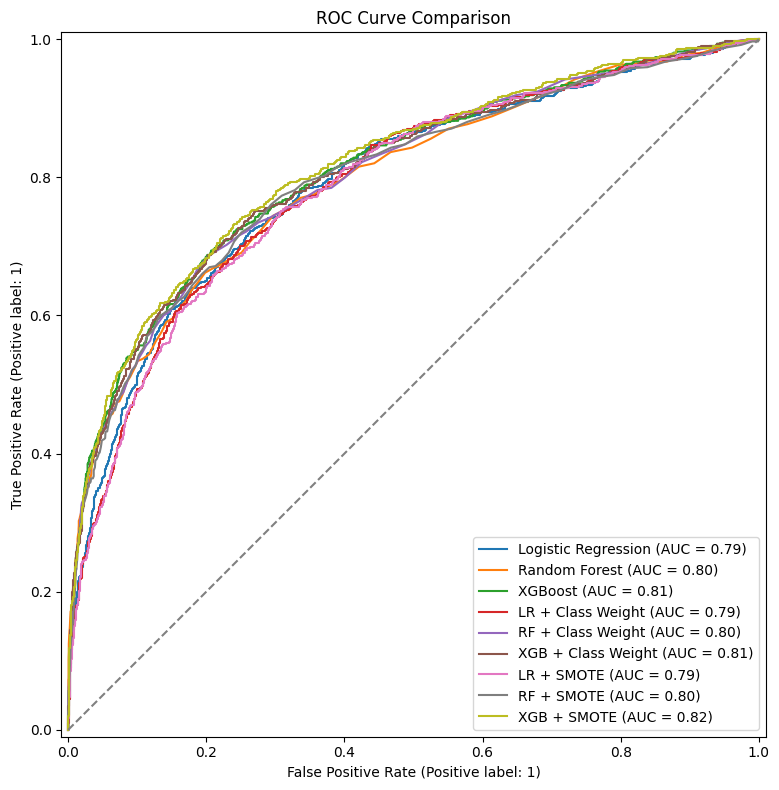

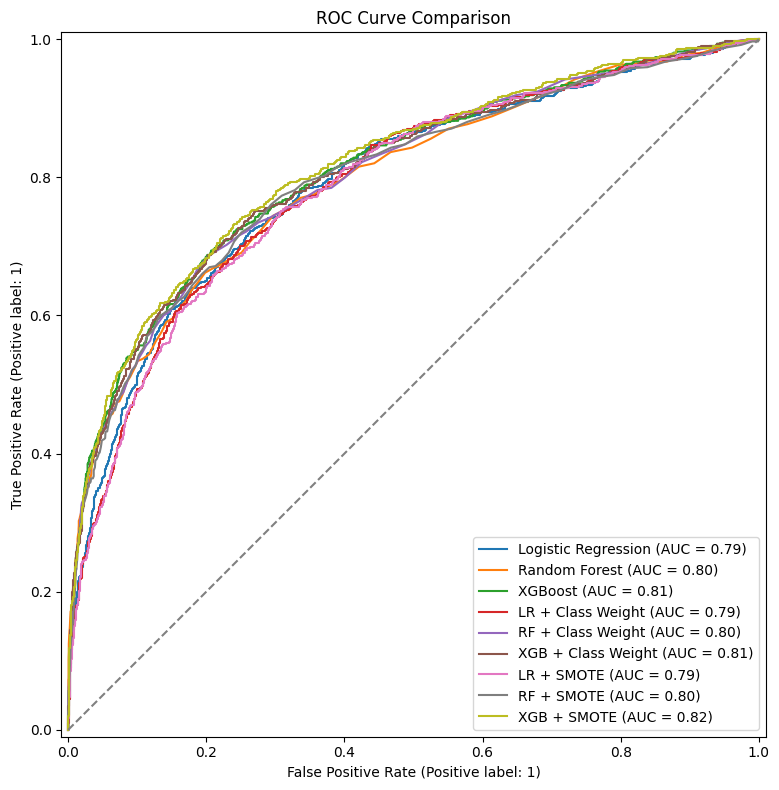

In [147]:
fig, ax = plt.subplots(figsize=(9, 8))

for name, pipe in models.items():
    RocCurveDisplay.from_estimator(
        pipe,
        X_test,
        y_test,
        ax=ax,
        name=name)
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Chance"
)

ax.set_title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

The ROC curves show that all nine models perform substantially better than random guessing, as each curve lies well above the diagonal reference line. The models achieved ROC-AUC values between 0.79 and 0.82, indicating good discrimination between borrowers who defaulted and those who repaid their loans.

Although the ROC curves appear similar, the XGBoost with SMOTE model achieved the highest ROC-AUC (≈0.82), followed closely by the baseline and class-weighted XGBoost models (≈0.81). This suggests that XGBoost consistently provides the strongest ability to distinguish high-risk borrowers across different classification thresholds.

However, because the dataset is imbalanced, ROC-AUC alone is not sufficient for selecting the final model. Greater emphasis is placed on Recall and F1-score, since correctly identifying borrowers who are likely to default is more valuable to lenders than maximizing overall classification accuracy.

# Feature Importance



Understanding which borrower characteristics influence model predictions is essential for interpreting loan default risk. Unlike overall performance metrics, feature importance identifies the variables that contribute most strongly to the model's decision-making process.

For tree-based models such as Random Forest and XGBoost, feature importance represents the relative contribution of each feature to reducing prediction error across the ensemble of decision trees. Examining these rankings helps identify the strongest drivers of loan default and provides valuable insights for credit risk assessment.

In [148]:
def plot_feature_importance(name, pipeline, top_n=15):

    preprocessor = pipeline.named_steps["preprocessor"]
    classifier = pipeline.named_steps["classifier"]
    feature_names = preprocessor.get_feature_names_out()

    if hasattr(classifier, "feature_importances_"):
        importance = classifier.feature_importances_
    elif hasattr(classifier, "coef_"):
        importance = np.abs(classifier.coef_[0])

    else:
        raise ValueError("Model does not support feature importance.")

    importance_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": importance
        }).sort_values("Importance", ascending=False).head(top_n))

    plt.figure(figsize=(8,6))
    plt.barh(
        importance_df["Feature"][::-1],
        importance_df["Importance"][::-1]
    )

    plt.title(f"Top {top_n} Important Features\n{name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    return importance_df

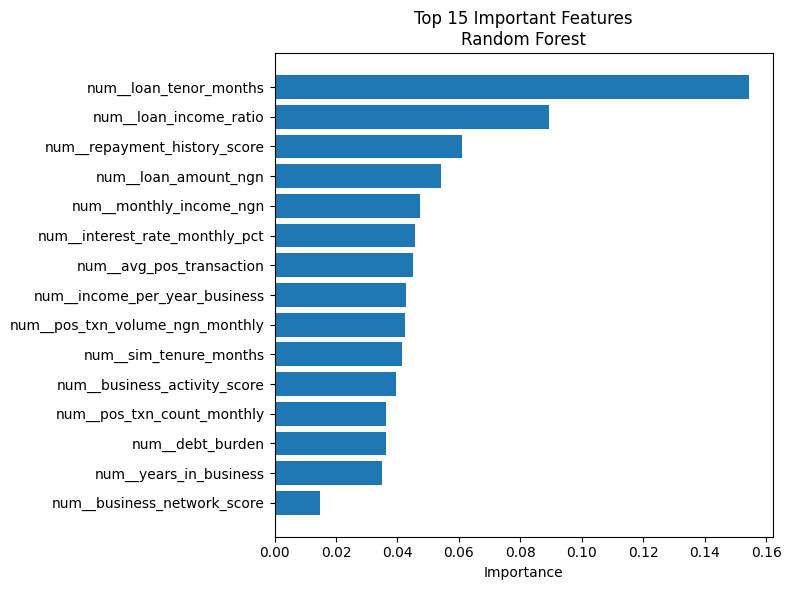

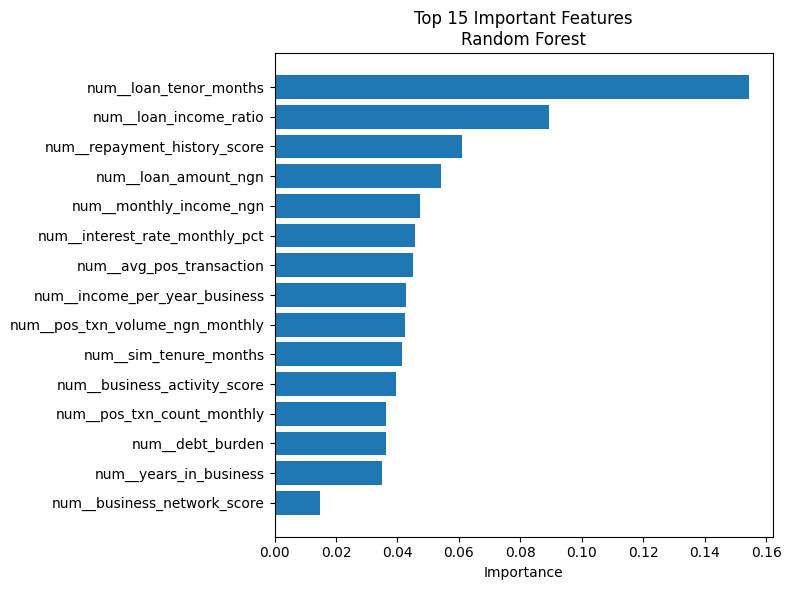

In [149]:
rf_importance = plot_feature_importance(
    "Random Forest",
    rf_pipeline)

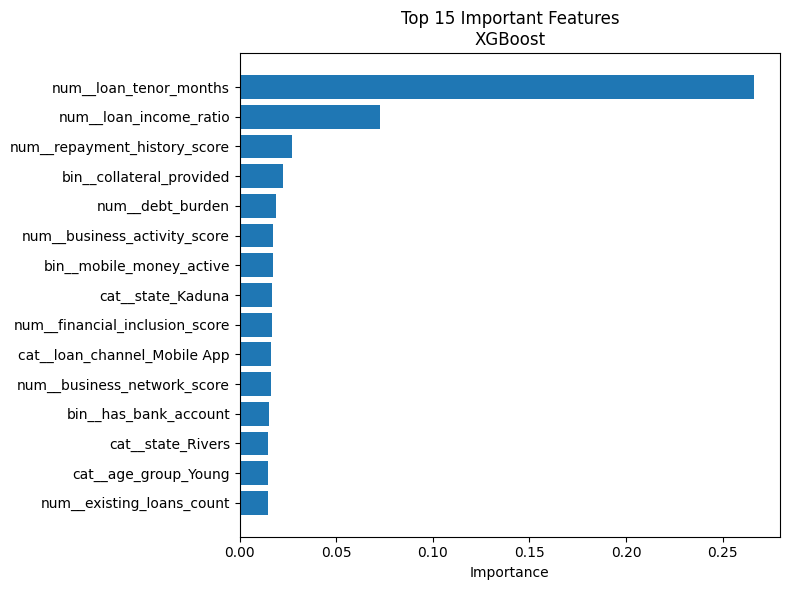

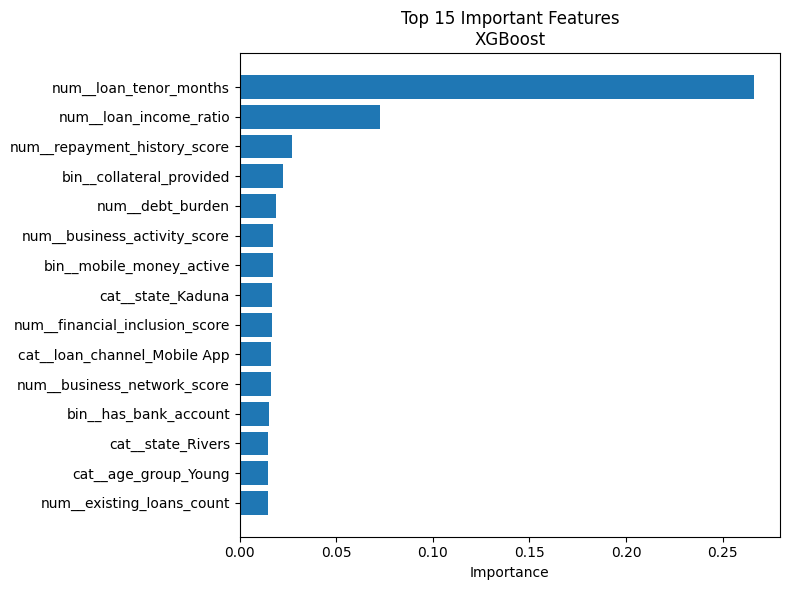

In [150]:
xgb_importance = plot_feature_importance(
    "XGBoost",
    xgb_pipeline)


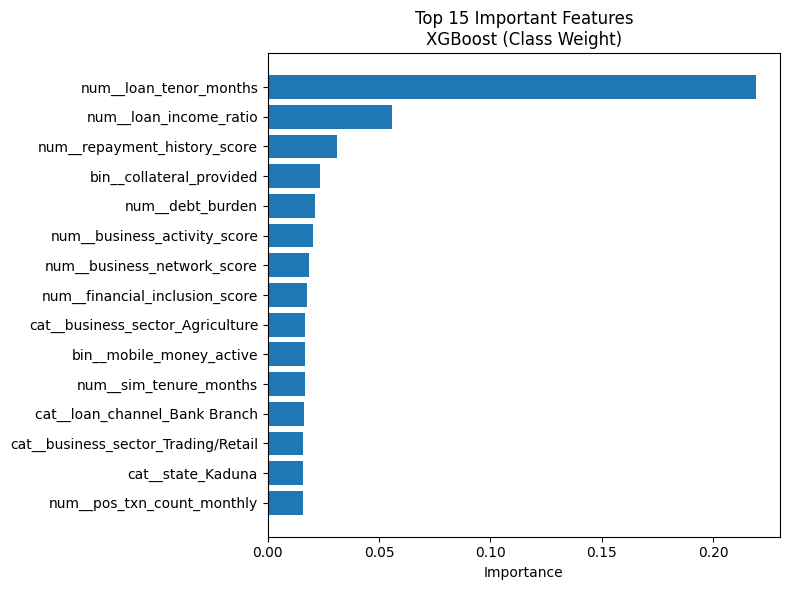

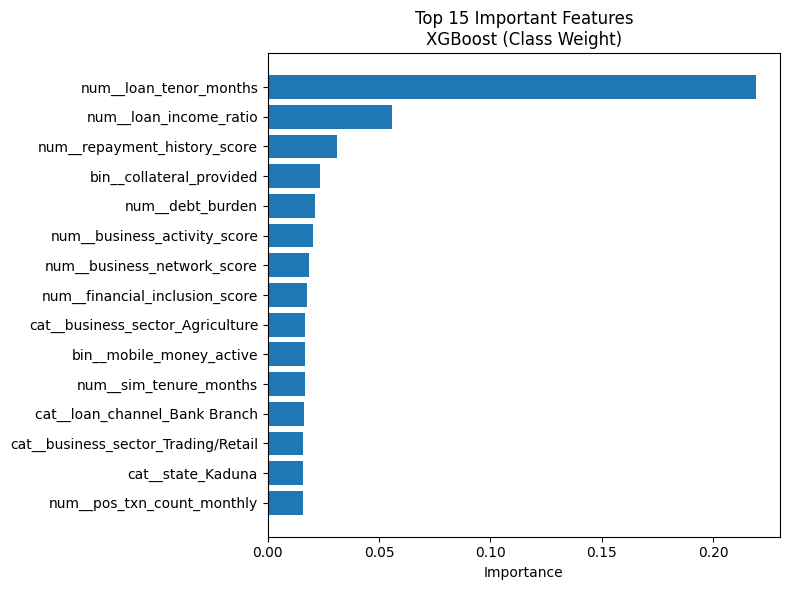

In [151]:
xgb_weighted_importance = plot_feature_importance(
    "XGBoost (Class Weight)",
    xgb_weighted_pipeline)

# **Risk Scoring Demo:** Manual Input & CSV Upload

To demonstrate how the trained model can support lending decisions, a simple risk scoring function was developed. Given information about a loan applicant, the model estimates the probability of default and assigns the applicant to a corresponding risk category.

The same prediction function can be applied to a single applicant through manual input or to multiple applicants through a CSV file, making it suitable for practical deployment by micro-lenders or POS agents.

In [152]:
# Select the final model
best_model = xgb_weighted_pipeline

In [153]:
# Risk Bands
RISK_BANDS = [
    (0.30, "Low Risk"),
    (0.60, "Medium Risk"),
    (1.01, "High Risk")
]


def risk_band(prob):

    for threshold, label in RISK_BANDS:

        if prob < threshold:
            return label

    return "High Risk"

## Manual Prediction

In [154]:
# Manual Prediction Function
def score_applicant(record, pipeline=best_model):

    applicant = pd.DataFrame([record])
    probability = float(pipeline.predict_proba(applicant)[0, 1])

    return {
        "Risk Score (%)": round(probability * 100, 2),
        "Risk Band": risk_band(probability)
    }

In [155]:
# Manual Applicant Example
sample_applicant = {

    "years_in_business":2.5,
    "monthly_income_ngn":65000,
    "pos_txn_count_monthly":55,
    "pos_txn_volume_ngn_monthly":220000,
    "loan_amount_ngn":90000,
    "loan_tenor_months":6,
    "interest_rate_monthly_pct":6.5,
    "existing_loans_count":2,
    "sim_tenure_months":40,
    "repayment_history_score":58,
    "loan_income_ratio":1.38,
    "avg_pos_transaction":4000,
    "income_per_year_business":26000,
    "debt_burden":90000,
    "financial_inclusion_score":3,
    "business_activity_score":140,
    "business_network_score":2.5,
    "collateral_provided":0,
    "has_bank_account":1,
    "trade_association_member":0,
    "mobile_money_active":1,
    "age_group":"Young",
    "gender":"Female",
    "state":"Lagos",
    "business_sector":"Trading/Retail",
    "urban_rural":"Urban",
    "loan_channel":"POS Agent"

}

score_applicant(sample_applicant)

{'Risk Score (%)': 30.74, 'Risk Band': 'Medium Risk'}

{'Risk Score (%)': 30.74, 'Risk Band': 'Medium Risk'}

## CSV Batch Demo

In addition to evaluating individual applicants, the model can process multiple loan applications stored in a CSV file. Each applicant is assigned a predicted probability of default together with a corresponding risk category. This functionality demonstrates how the model could support financial institutions in screening large numbers of loan applications efficiently.

In [156]:
batch_sample = X_test.sample(10, random_state=RANDOM_STATE).copy()

scores = []
bands = []

for _, row in batch_sample.iterrows():
    result = score_applicant(row.to_dict())
    scores.append(result["Risk Score (%)"])
    bands.append(result["Risk Band"])

batch_sample["Risk Score (%)"] = scores
batch_sample["Risk Band"] = bands
batch_sample

,years_in_business,monthly_income_ngn,pos_txn_count_monthly,pos_txn_volume_ngn_monthly,loan_amount_ngn,loan_tenor_months,interest_rate_monthly_pct,existing_loans_count,sim_tenure_months,repayment_history_score,...,trade_association_member,mobile_money_active,age_group,gender,state,business_sector,urban_rural,loan_channel,Risk Score (%),Risk Band
2131,7.7,21200,107,343800,47000,1,6.79,0,7,100.0,...,1,1,Senior,Male,Oyo,Electronics/Phone Accessories,Urban,Mobile App,77.06,High Risk
12421,2.3,53400,44,149200,109000,6,9.68,0,32,74.3,...,0,1,Young,Male,Lagos,Transport/Logistics,Urban,POS Agent,33.91,Medium Risk
9086,1.5,32200,31,160300,14000,2,6.01,1,20,83.1,...,0,1,Middle,Female,Rivers,Services (Salon/Barbing etc.),Urban,Mobile App,3.64,Low Risk
7412,4.7,43200,74,200900,75000,12,8.51,2,88,58.1,...,0,1,Middle,Male,Delta,Agriculture,Urban,POS Agent,23.65,Low Risk
16416,1.6,15000,26,26700,25000,9,5.70,1,108,59.9,...,1,1,Middle,Male,Enugu,Transport/Logistics,Rural,Mobile App,24.79,Low Risk
8270,2.0,42600,32,44800,88000,6,6.69,1,33,28.8,...,1,1,Adult,Male,Enugu,Agriculture,Urban,Cooperative (Esusu/Ajo),44.52,Medium Risk
919,4.2,135400,63,240100,112000,2,10.18,0,25,67.2,...,0,0,Middle,Male,Oyo,Services (Salon/Barbing etc.),Urban,POS Agent,18.10,Low Risk
7769,3.6,36500,55,217600,39000,3,10.16,0,113,76.0,...,0,0,Senior,Female,Anambra,Transport/Logistics,Urban,Mobile App,20.47,Low Risk
4865,3.9,46500,64,237300,80000,3,10.11,1,33,58.0,...,1,1,Middle,Male,Delta,Electronics/Phone Accessories,Urban,Cooperative (Esusu/Ajo),51.99,Medium Risk
14701,8.2,35200,128,761100,64000,2,4.36,1,82,66.3,...,1,0,Young,Male,Ogun,Trading/Retail,Urban,Cooperative (Esusu/Ajo),45.43,Medium Risk


,years_in_business,monthly_income_ngn,pos_txn_count_monthly,pos_txn_volume_ngn_monthly,loan_amount_ngn,loan_tenor_months,interest_rate_monthly_pct,existing_loans_count,sim_tenure_months,repayment_history_score,...,trade_association_member,mobile_money_active,age_group,gender,state,business_sector,urban_rural,loan_channel,Risk Score (%),Risk Band
2131,7.7,21200,107,343800,47000,1,6.79,0,7,100.0,...,1,1,Senior,Male,Oyo,Electronics/Phone Accessories,Urban,Mobile App,77.06,High Risk
12421,2.3,53400,44,149200,109000,6,9.68,0,32,74.3,...,0,1,Young,Male,Lagos,Transport/Logistics,Urban,POS Agent,33.91,Medium Risk
9086,1.5,32200,31,160300,14000,2,6.01,1,20,83.1,...,0,1,Middle,Female,Rivers,Services (Salon/Barbing etc.),Urban,Mobile App,3.64,Low Risk
7412,4.7,43200,74,200900,75000,12,8.51,2,88,58.1,...,0,1,Middle,Male,Delta,Agriculture,Urban,POS Agent,23.65,Low Risk
16416,1.6,15000,26,26700,25000,9,5.70,1,108,59.9,...,1,1,Middle,Male,Enugu,Transport/Logistics,Rural,Mobile App,24.79,Low Risk
8270,2.0,42600,32,44800,88000,6,6.69,1,33,28.8,...,1,1,Adult,Male,Enugu,Agriculture,Urban,Cooperative (Esusu/Ajo),44.52,Medium Risk
919,4.2,135400,63,240100,112000,2,10.18,0,25,67.2,...,0,0,Middle,Male,Oyo,Services (Salon/Barbing etc.),Urban,POS Agent,18.10,Low Risk
7769,3.6,36500,55,217600,39000,3,10.16,0,113,76.0,...,0,0,Senior,Female,Anambra,Transport/Logistics,Urban,Mobile App,20.47,Low Risk
4865,3.9,46500,64,237300,80000,3,10.11,1,33,58.0,...,1,1,Middle,Male,Delta,Electronics/Phone Accessories,Urban,Cooperative (Esusu/Ajo),51.99,Medium Risk
14701,8.2,35200,128,761100,64000,2,4.36,1,82,66.3,...,1,0,Young,Male,Ogun,Trading/Retail,Urban,Cooperative (Esusu/Ajo),45.43,Medium Risk


In [157]:
from google.colab import files

def predict_uploaded_csv(pipeline=best_model):
    """
    Upload a CSV file, score every applicant,
    and return/download the predictions.
    """

    uploaded = files.upload()

    if len(uploaded) == 0:
        print("No file uploaded.")
        return None

    filename = list(uploaded.keys())[0]
    df_upload = pd.read_csv(filename)

    # Keep only model features
    X_upload = df_upload[ALL_FEATURES].copy()

    # Predict probabilities
    probabilities = pipeline.predict_proba(X_upload)[:, 1]

    # Add predictions
    results = df_upload.copy()

    results["Risk Score (%)"] = (probabilities * 100).round(2)
    results["Risk Band"] = [
        risk_band(p) for p in probabilities
    ]

    print(f"{len(results)} applicants scored successfully.")
    display(results.head())
    output_name = "loan_risk_predictions.csv"
    results.to_csv(output_name, index=False)
    files.download(output_name)

    return results

In [174]:
batch_predictions = predict_uploaded_csv()

Saving default_record.csv to default_record (2).csv
12 applicants scored successfully.


,years_in_business,monthly_income_ngn,pos_txn_count_monthly,pos_txn_volume_ngn_monthly,loan_amount_ngn,loan_tenor_months,interest_rate_monthly_pct,existing_loans_count,sim_tenure_months,repayment_history_score,...,trade_association_member,mobile_money_active,age_group,gender,state,business_sector,urban_rural,loan_channel,Risk Score (%),Risk Band
0,7.5,37300,109,252300,90000,12,3.06,1,27,77.5,...,1,1,Adult,Female,Oyo,Fashion & Tailoring,Urban,Mobile App,10.750000,Low Risk
1,5.8,58500,85,446500,25000,3,8.14,1,51,48.3,...,0,0,Young,Male,Anambra,Trading/Retail,Rural,POS Agent,36.439999,Medium Risk
2,3.2,52600,41,57100,122000,2,9.00,0,74,78.3,...,0,0,Senior,Male,Ogun,Agriculture,Rural,Bank Branch,65.970001,High Risk
3,1.0,86900,21,110700,167000,2,3.57,0,54,63.2,...,0,0,Adult,Female,Delta,Electronics/Phone Accessories,Urban,POS Agent,50.570000,Medium Risk
4,0.7,205000,12,25800,101000,1,7.63,1,38,82.5,...,0,1,Young,Female,Kaduna,Trading/Retail,Urban,POS Agent,32.840000,Medium Risk


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

This project developed a machine learning-based loan default risk prediction system for Nigerian micro-lenders and POS agents. Three classification algorithms: Logistic Regression, Random Forest, and XGBoost, were evaluated using the original dataset, class weighting, and SMOTE oversampling techniques.

Among the evaluated models, XGBoost with class weighting achieved the best overall balance between Recall, F1-score, and ROC-AUC. Although class weighting slightly reduced overall accuracy, it substantially improved the model's ability to identify borrowers who were likely to default, which is the primary objective of credit risk assessment.

The final solution also includes a simple risk scoring function capable of evaluating individual borrowers or batches of applicants, demonstrating how machine learning can support faster and more consistent lending decisions.

# Limitations

Several limitations should be considered when interpreting the results.

- The dataset is synthetic and may not capture all complexities of real-world lending behavior.
- The target variable is imbalanced, making it challenging to accurately identify every defaulting borrower.
- Model performance depends on the quality and completeness of borrower information provided during prediction.
- Hyperparameter tuning was limited, meaning additional optimization may further improve predictive performance.
- External economic factors such as inflation, regional market conditions, and policy changes were not included in the feature set.